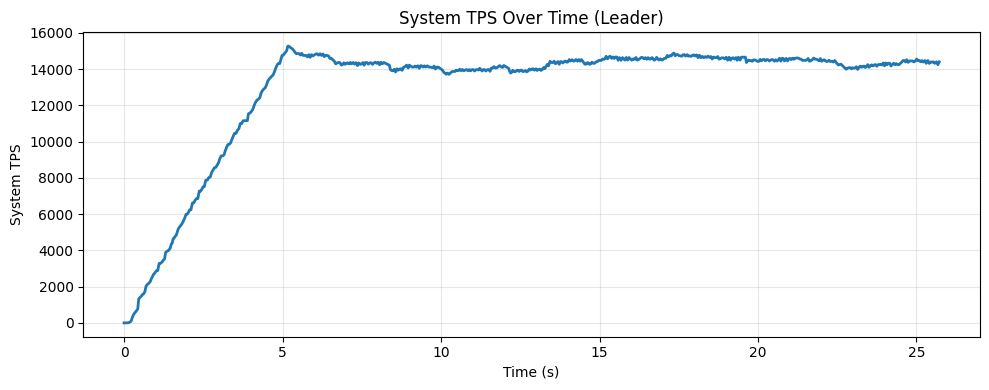

         Timestamp  SystemTPS
589  1775485965321    14406.0
590  1775485965364    14322.0
591  1775485965416    14404.0
592  1775485965461    14246.0
593  1775485965504    14406.0


In [38]:
import os
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "system_tps_global.csv"

if not os.path.exists(csv_path):
    print(f"{csv_path} not found. Run the experiment first.")
else:
    df = pd.read_csv(csv_path)
    if df.empty:
        print(f"{csv_path} is empty.")
    else:
        if "Timestamp" not in df.columns or "SystemTPS" not in df.columns:
            print("Expected columns: Timestamp,SystemTPS")
        else:
            df = df.sort_values("Timestamp").copy()
            df["time_s"] = (df["Timestamp"] - df["Timestamp"].iloc[0]) / 1000.0

            plt.figure(figsize=(10, 4))
            plt.plot(df["time_s"], df["SystemTPS"], linewidth=2, color="#1f77b4")
            plt.title("System TPS Over Time (Leader)")
            plt.xlabel("Time (s)")
            plt.ylabel("System TPS")
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()

            print(df[["Timestamp", "SystemTPS"]].tail())

Plotting System Metrics

1. Plotting TPS metrics...


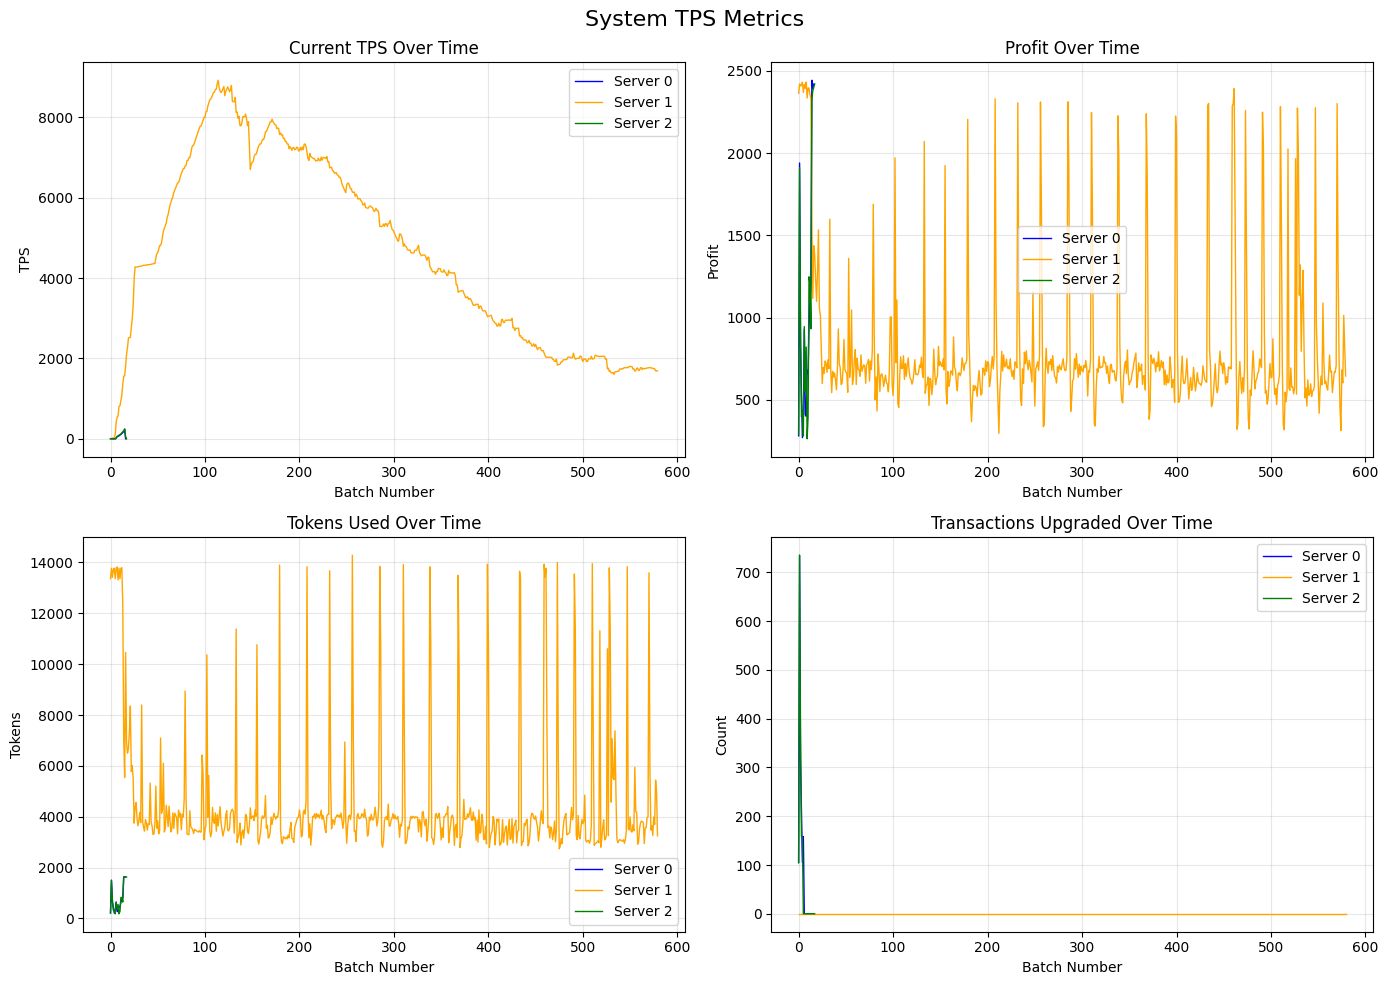


2. Plotting Incoming Transaction Rate...
File not found: ./incoming_transaction_rate_0.csv
File not found: ./incoming_transaction_rate_1.csv
File not found: ./incoming_transaction_rate_2.csv


/tmp/ipykernel_137135/63986126.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].grid(True, alpha=0.3); axes[0].legend()
/tmp/ipykernel_137135/63986126.py:80: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].grid(True, alpha=0.3); axes[1].legend()


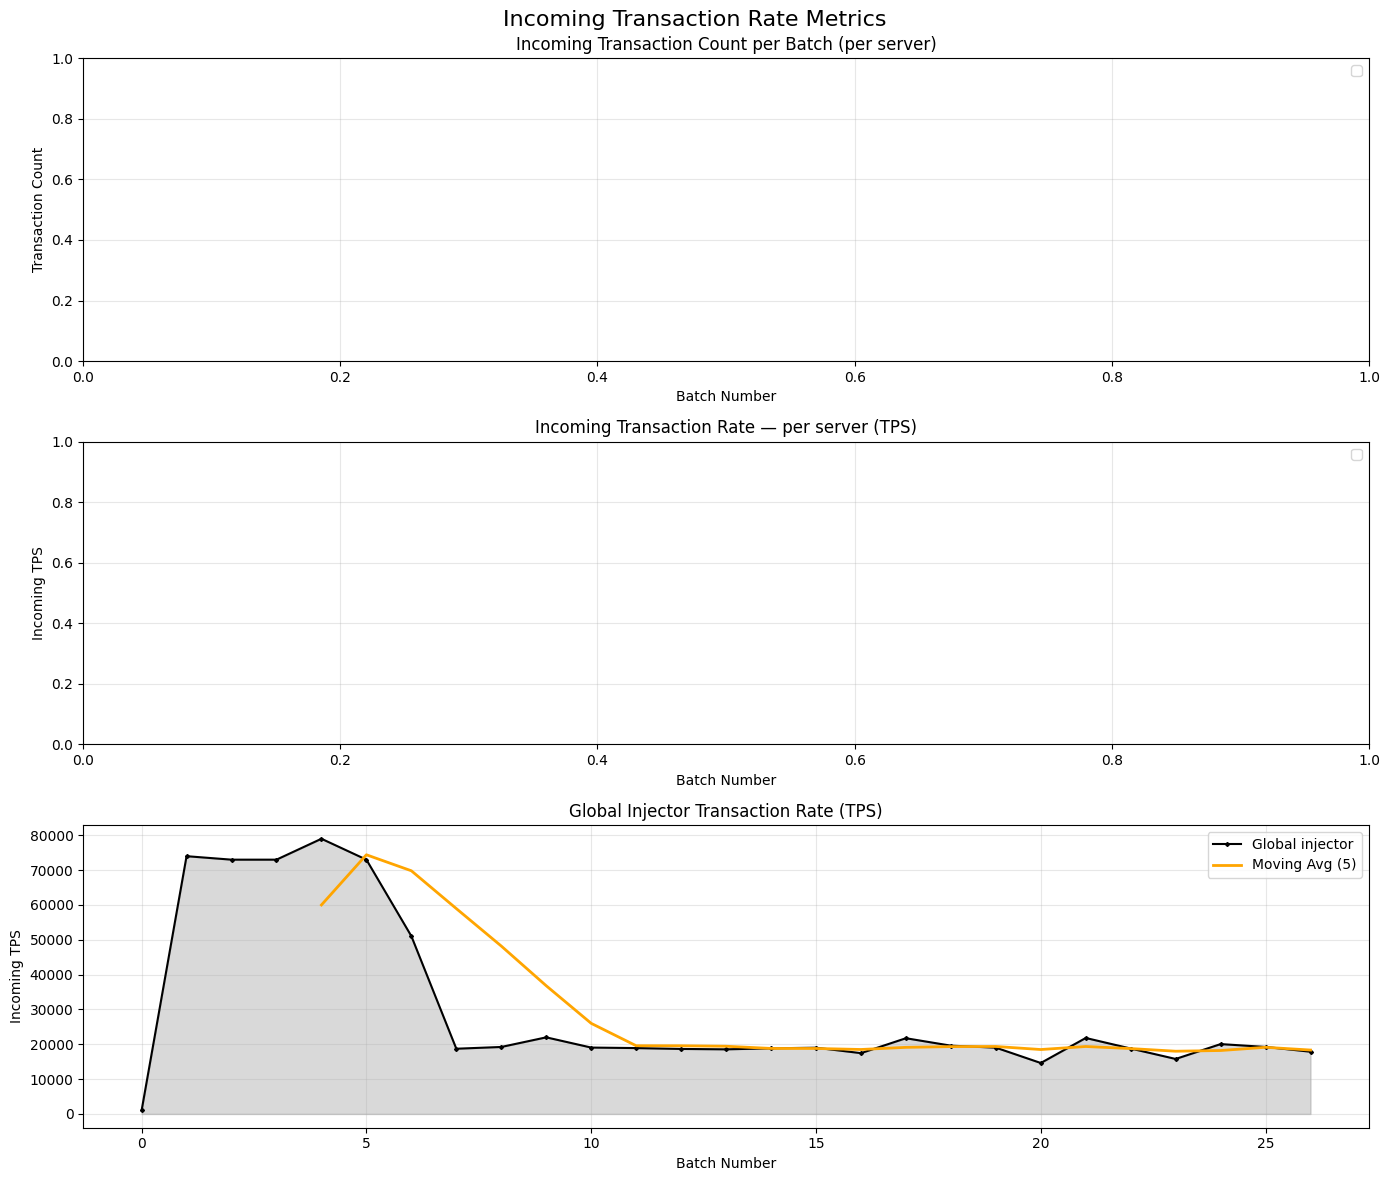


3. Plotting Backlog...
File not found: ./backlog_0.csv
File not found: ./backlog_1.csv
File not found: ./backlog_2.csv


/tmp/ipykernel_137135/63986126.py:133: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].grid(True, alpha=0.3); axes[0].legend()
/tmp/ipykernel_137135/63986126.py:137: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].grid(True, alpha=0.3); axes[1].legend()


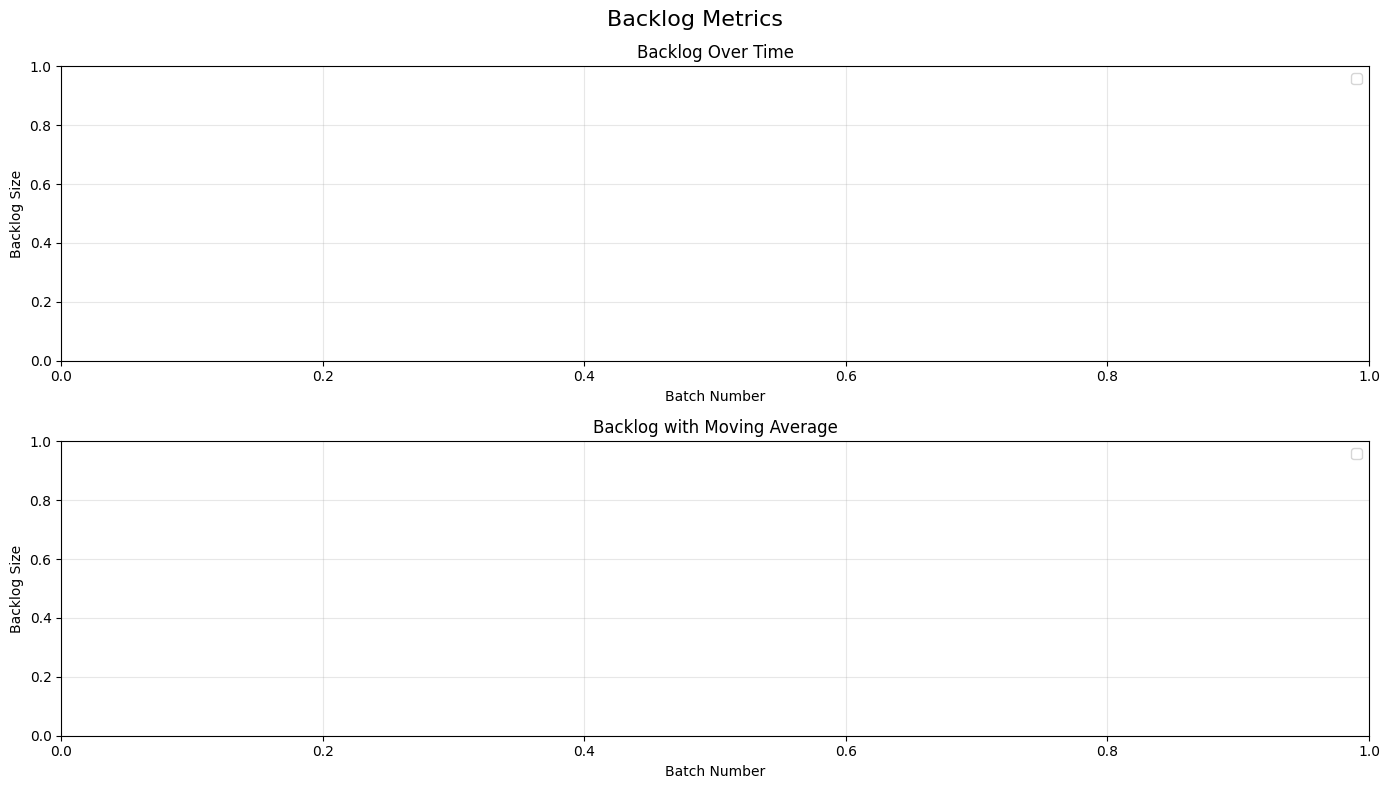


4. Plotting WriteConcern Frequency...


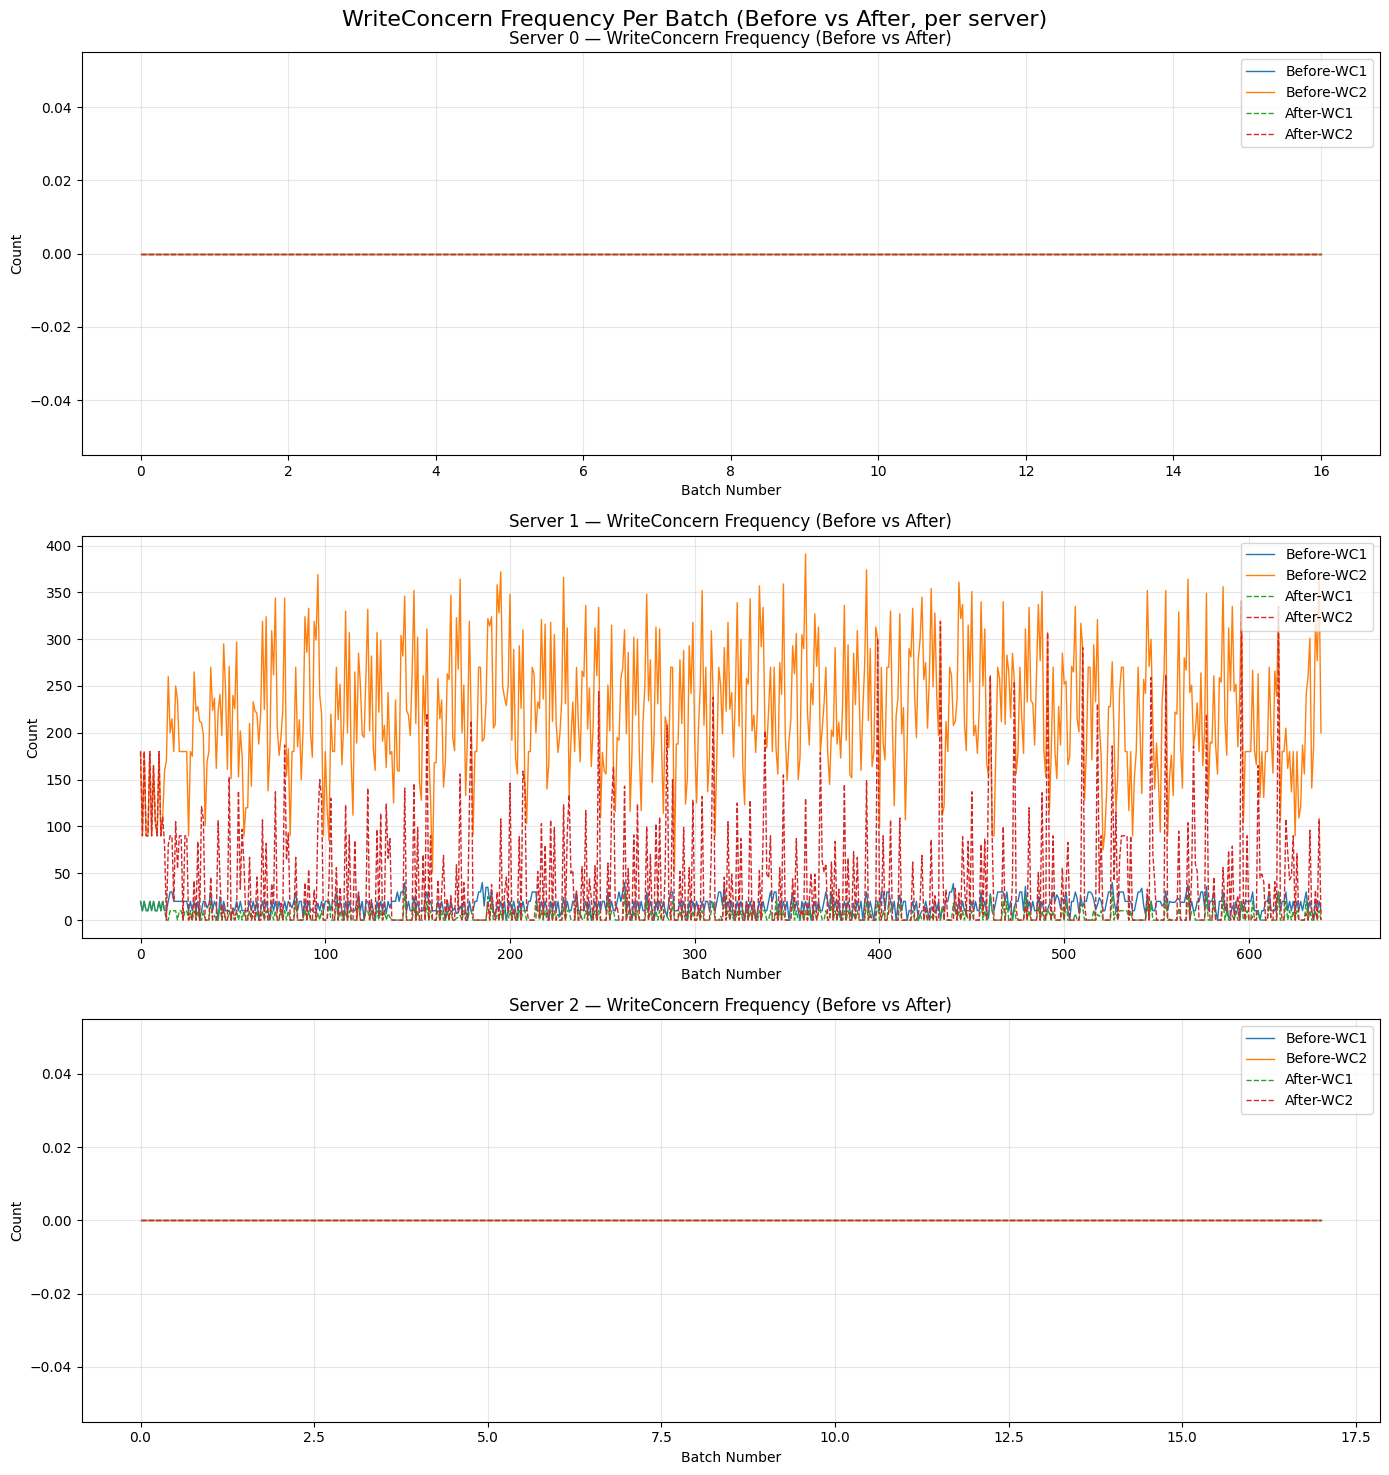


5. Plotting Read Mix (Before vs After)...


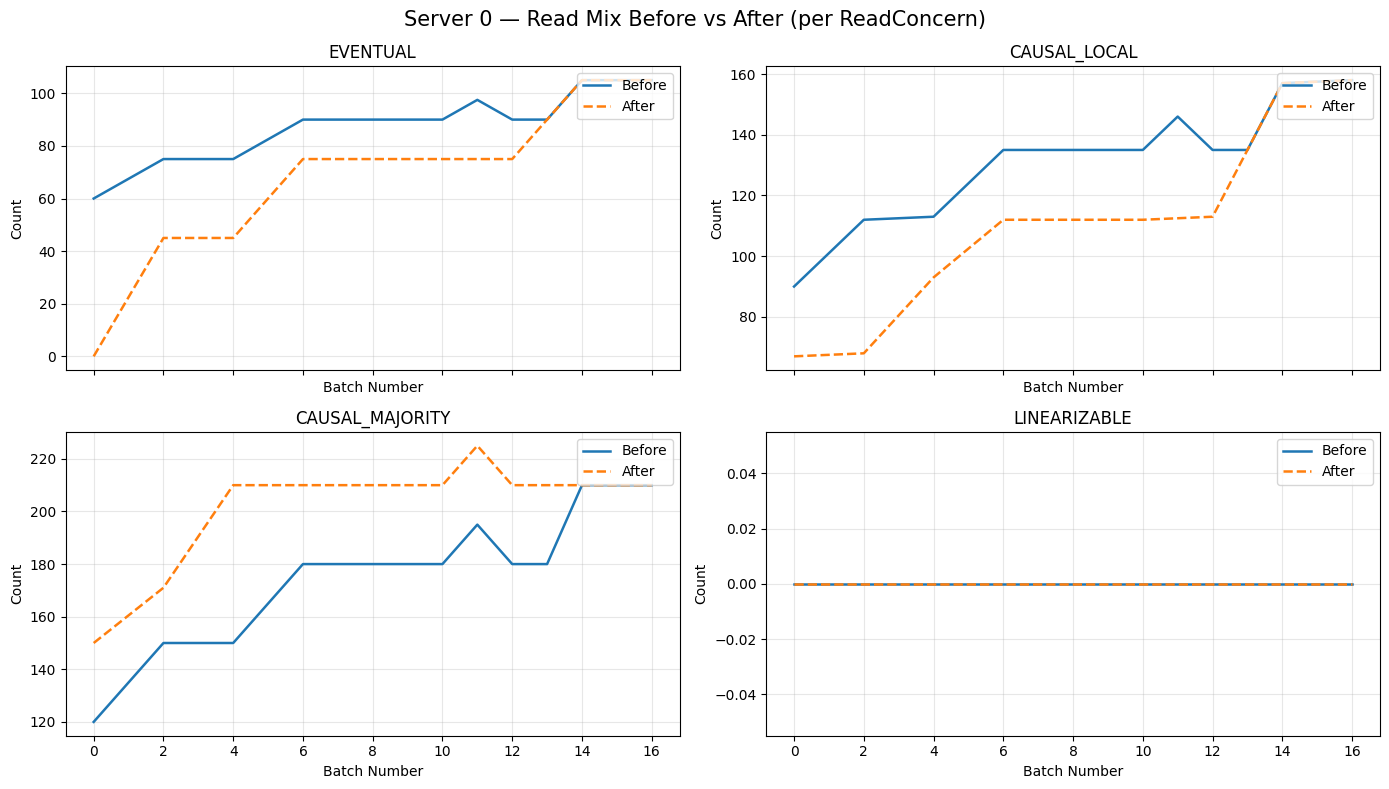

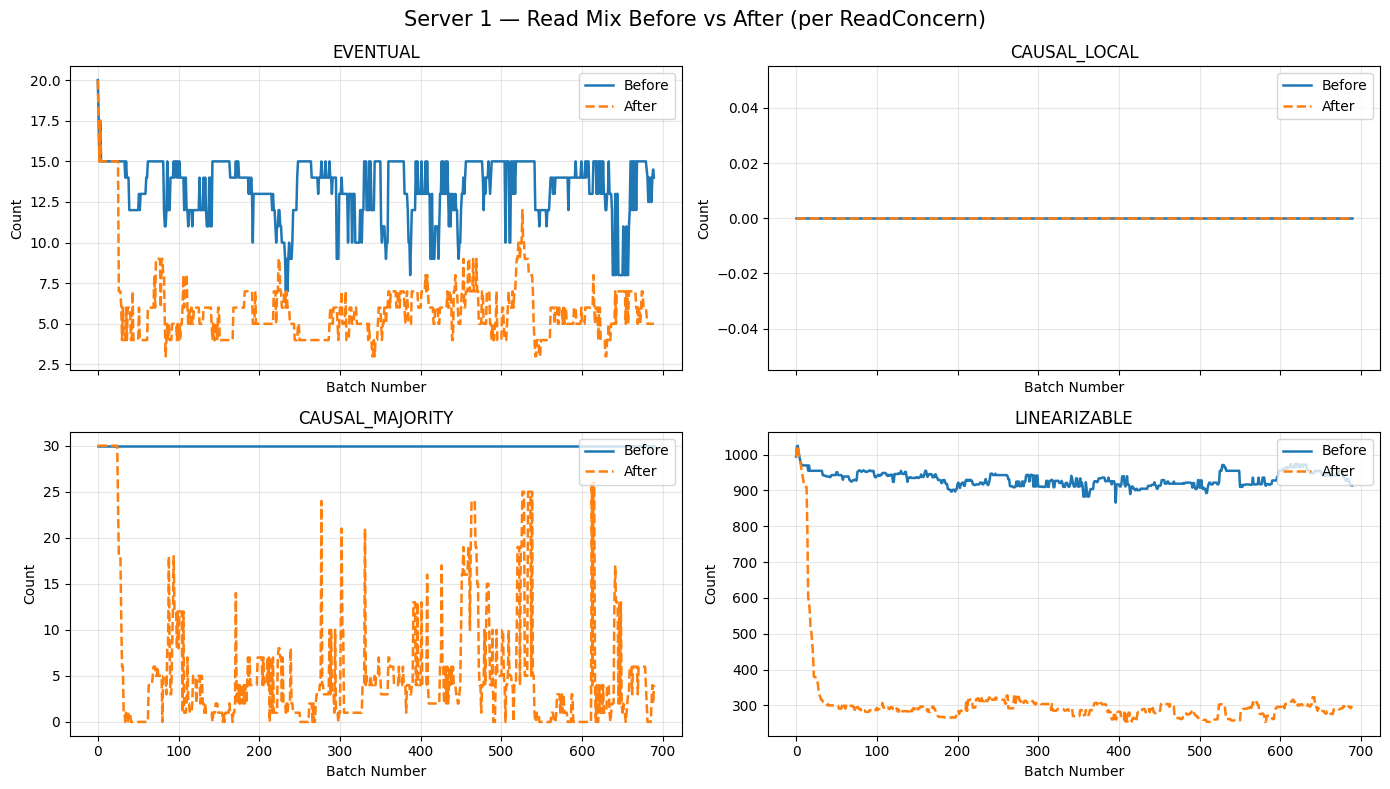

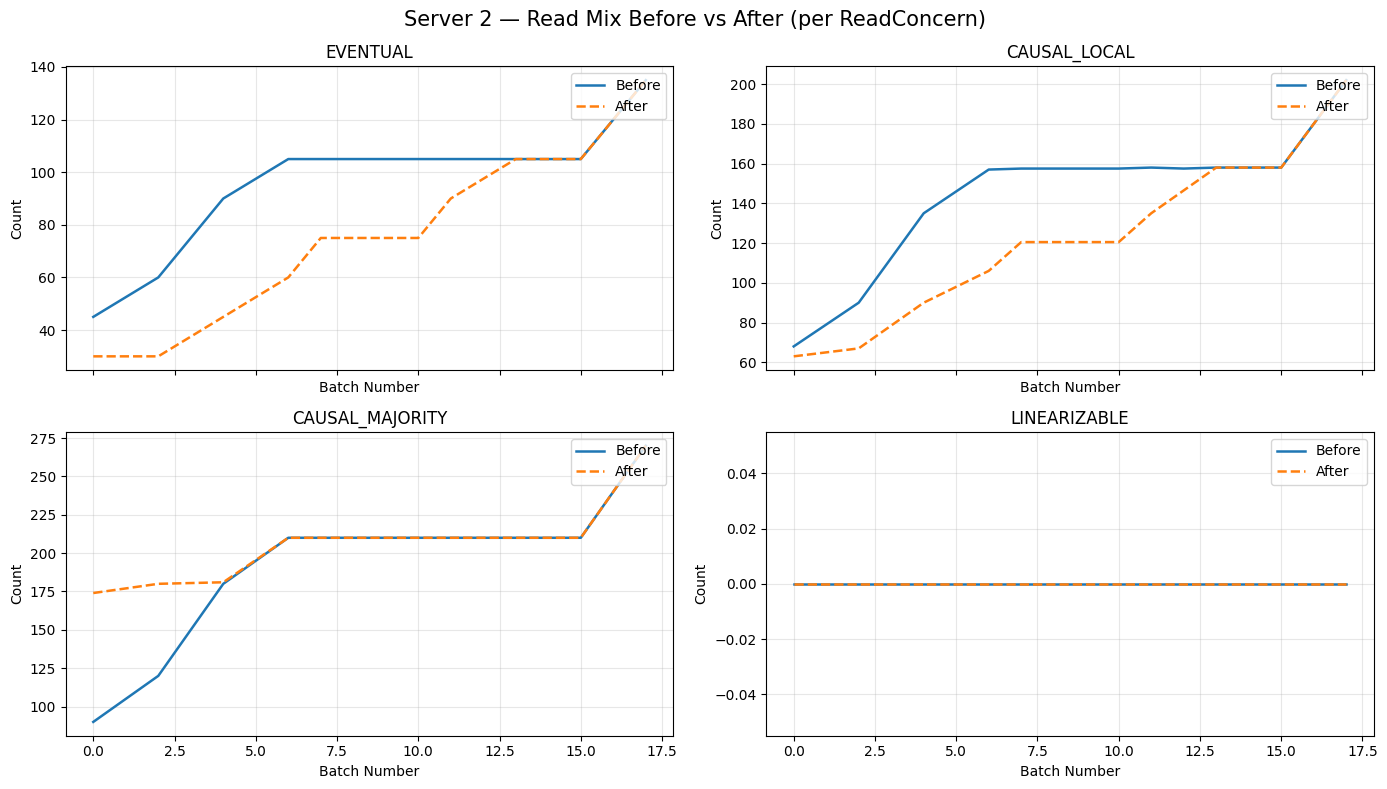


6. Plotting WriteConcern TPS...


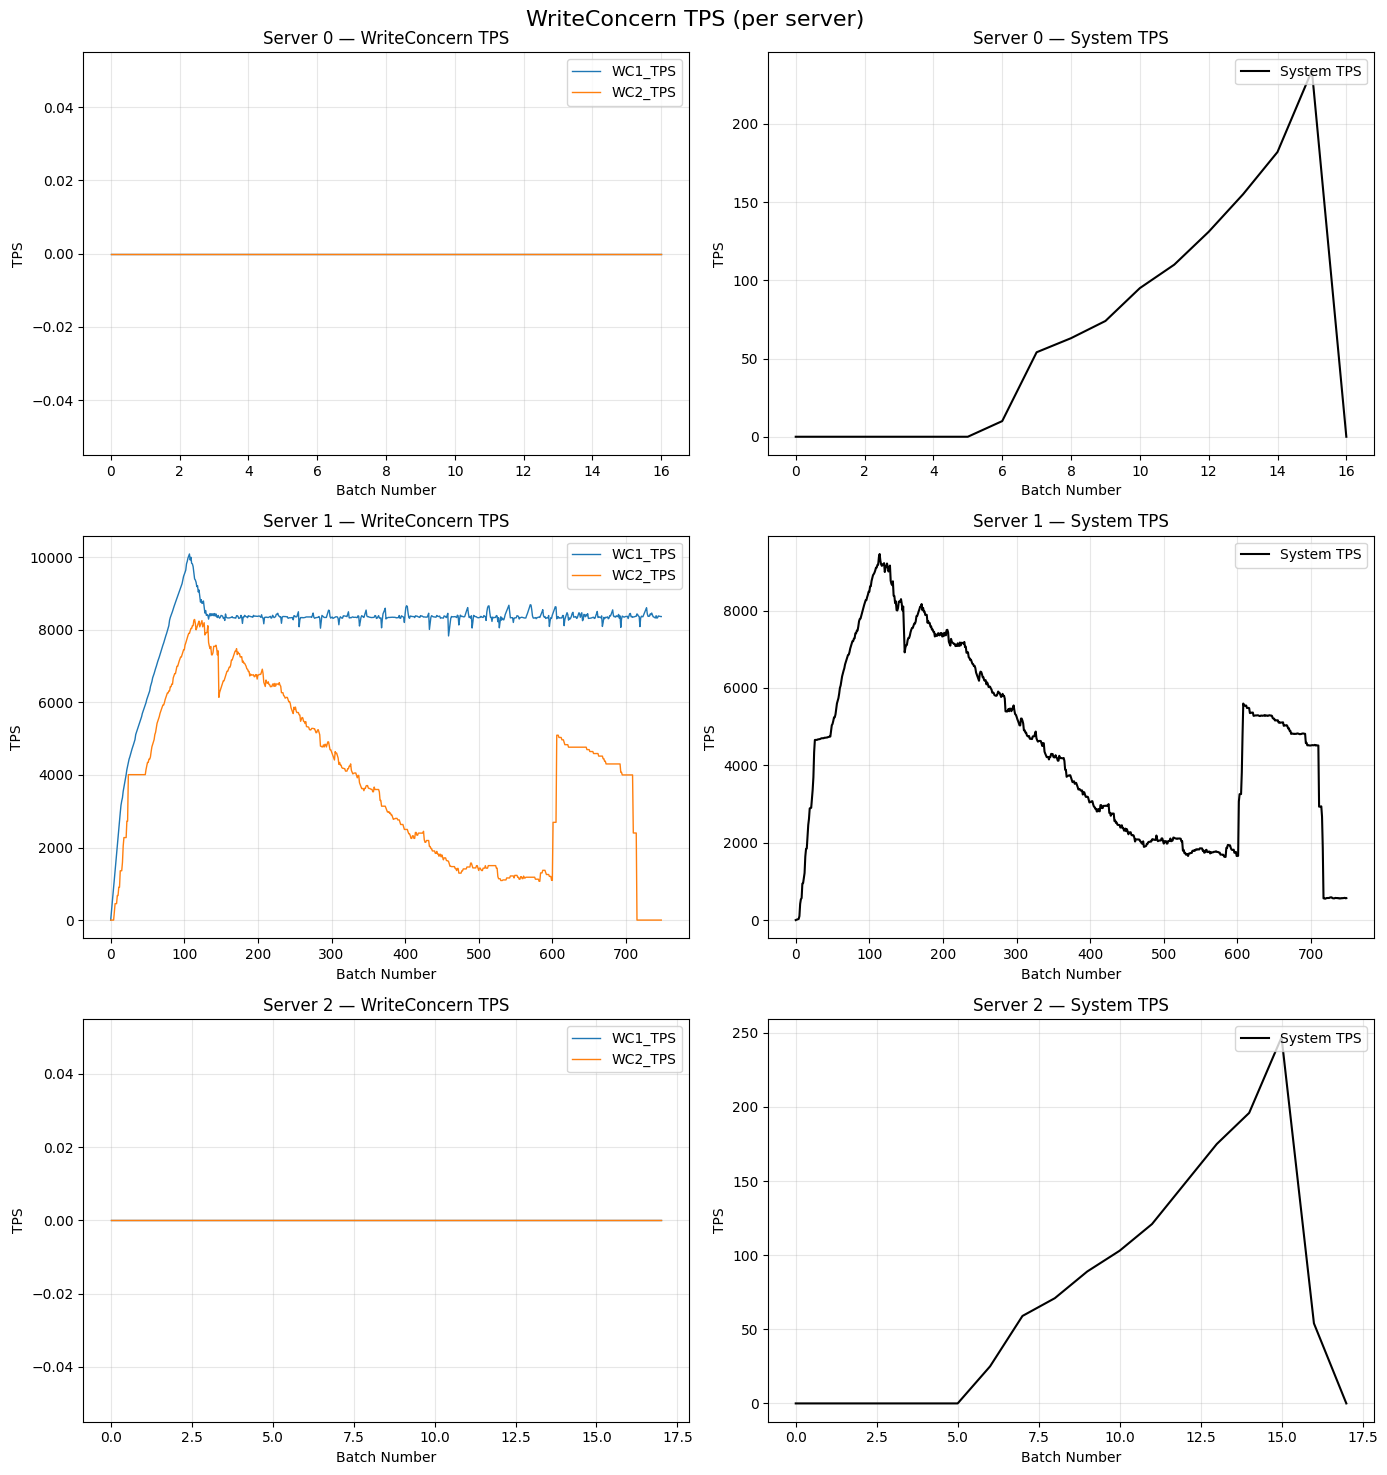


7. Plotting Final Batch Average TPS...
File not found: ./final_batch_avg_tps_log.csv

8. Plotting Combined Dashboard...


/tmp/ipykernel_137135/63986126.py:337: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].set_ylabel('Backlog Size'); axes[1].legend(loc='upper right'); axes[1].grid(True, alpha=0.3)


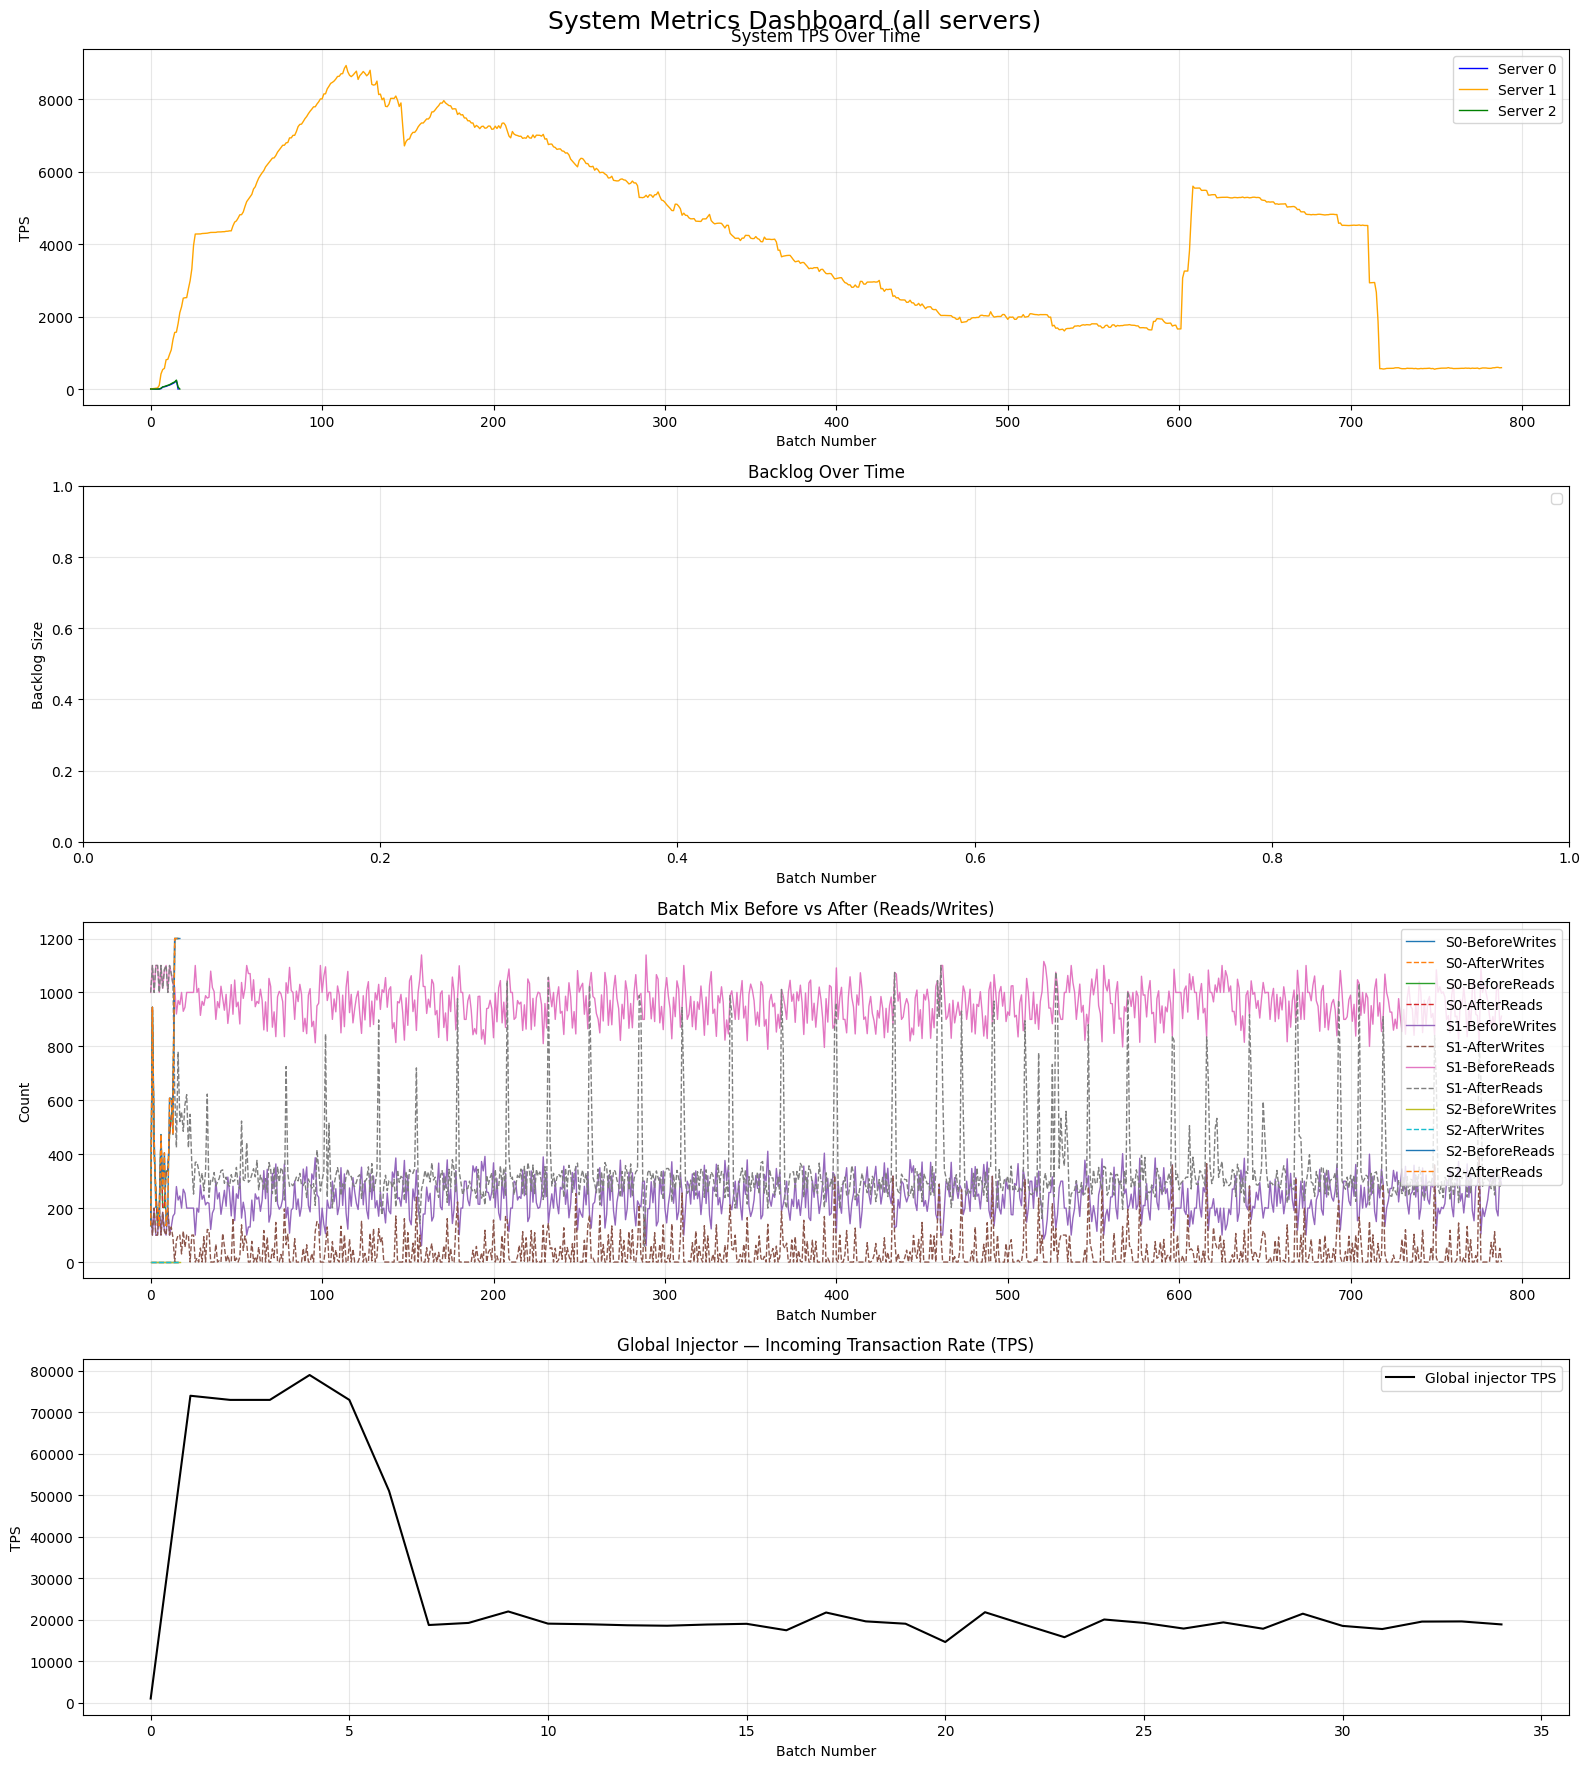


9. Plotting Stacked Area Chart...


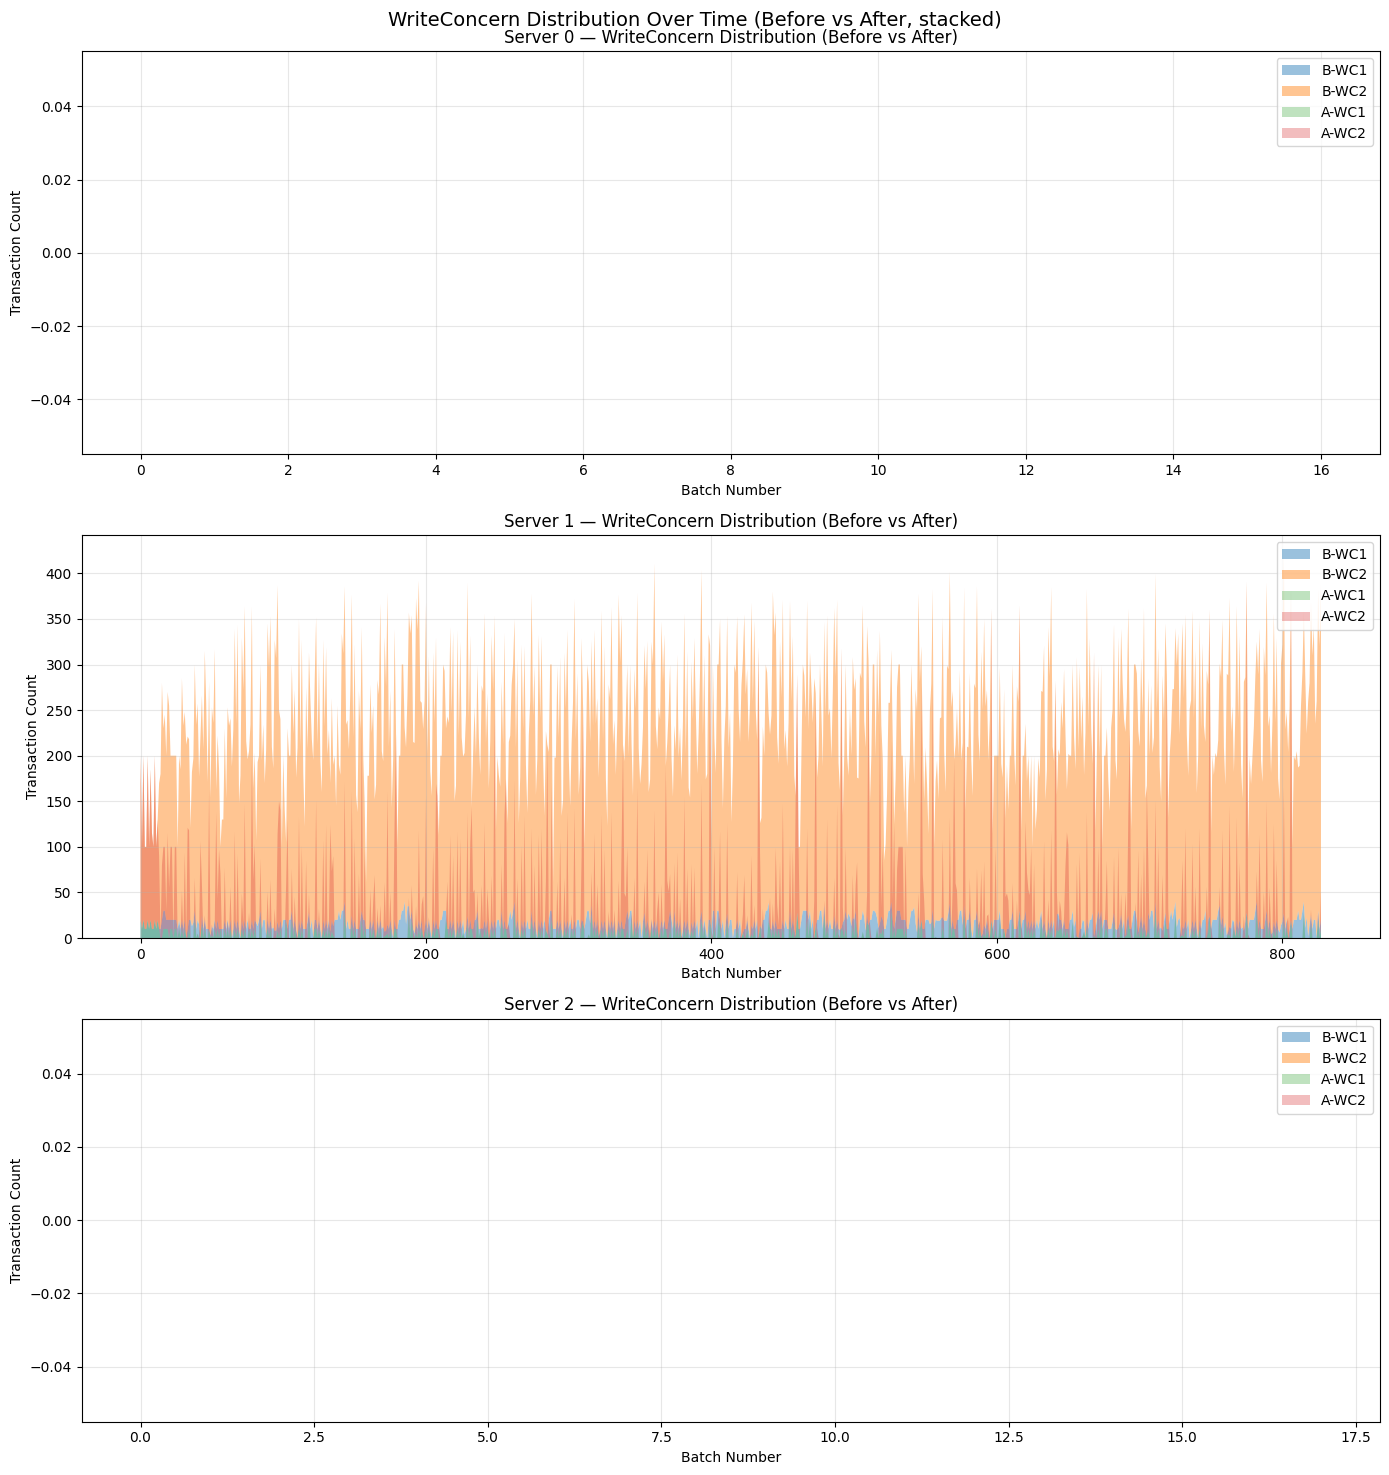


10. Plotting Workload Before Upgrade (Per Server)...


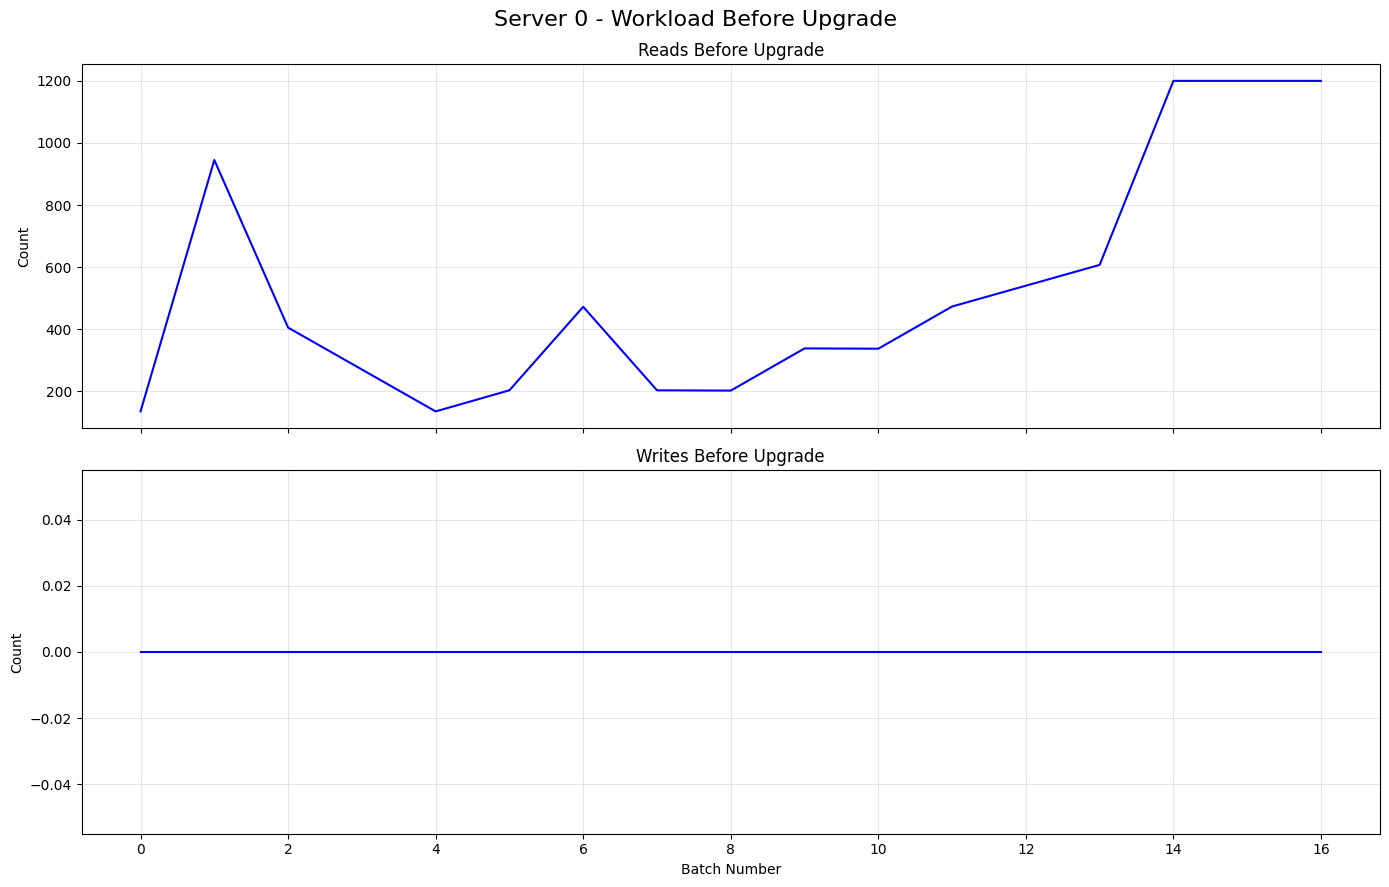

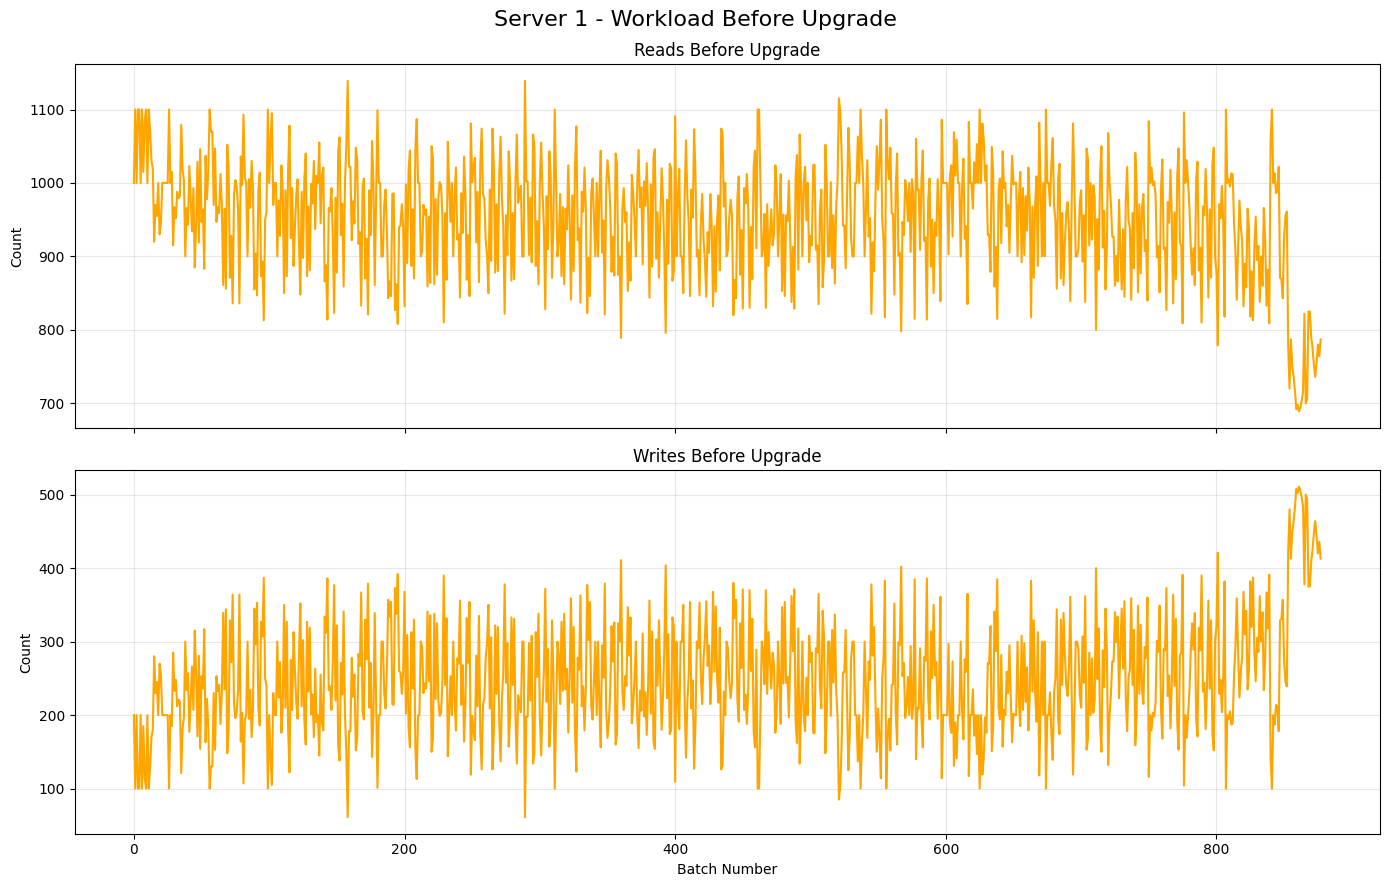

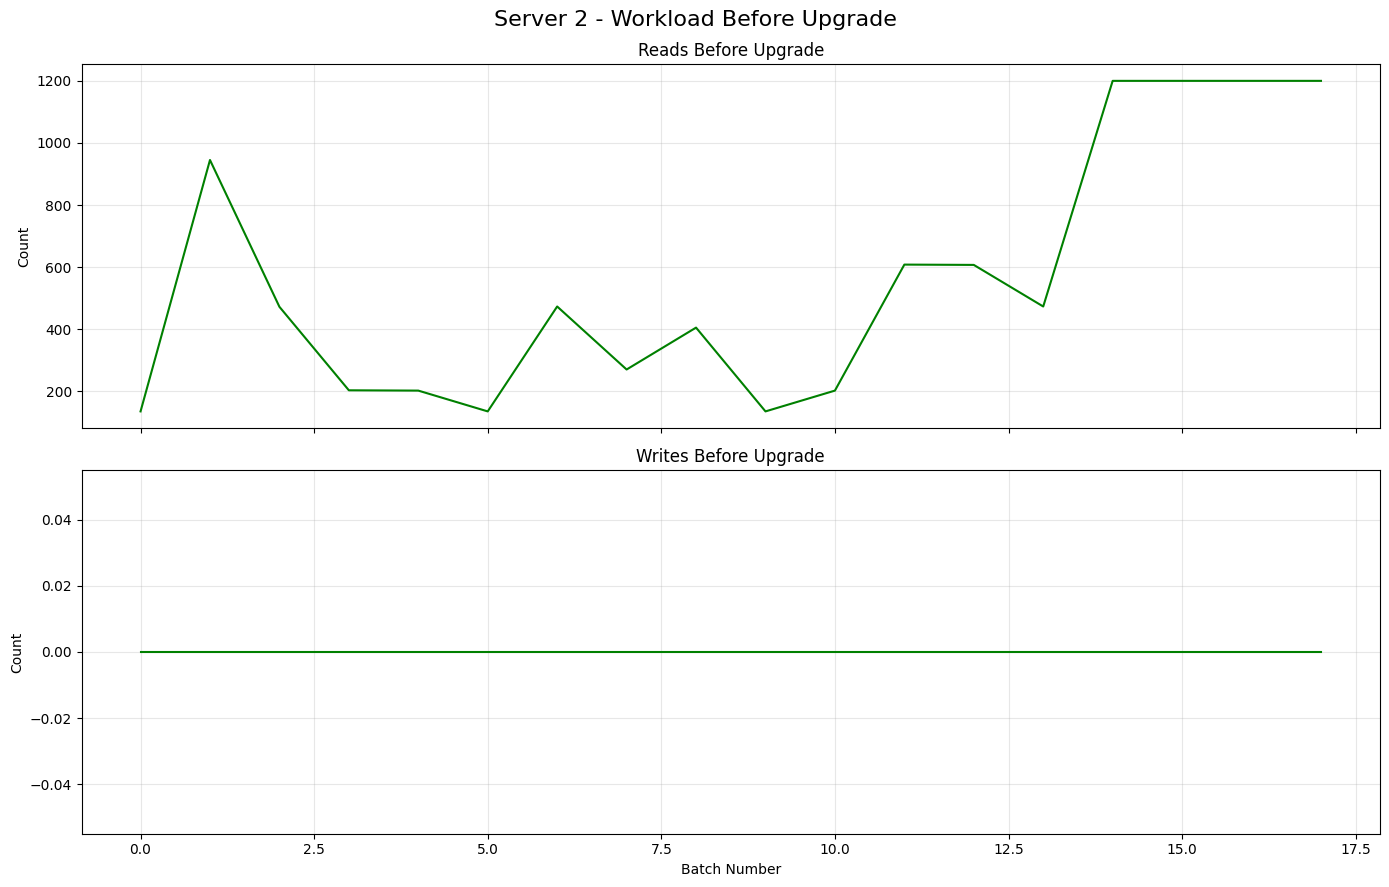


All plots generated successfully!


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Set the directory where CSV files are located
CSV_DIR = "."  # Change this if CSVs are in a different directory

# Server IDs — update to match the number of servers started in Servers.java
NUM_SERVERS = 3
SERVER_IDS = list(range(NUM_SERVERS))

COLORS = ['blue', 'orange', 'green', 'red', 'purple', 'brown']


def plot_tps(server_ids=SERVER_IDS):
    """Plot system TPS metrics from tps_<id>.csv for each server"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('System TPS Metrics', fontsize=16)

    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"tps_{sid}.csv")
        if not os.path.exists(filepath):
            print(f"File not found: {filepath}")
            continue
        df = pd.read_csv(filepath)
        color = COLORS[i % len(COLORS)]
        label = f"Server {sid}"
        axes[0, 0].plot(df.index, df['CurrentTPS'], color=color, linewidth=1, label=label)
        axes[0, 1].plot(df.index, df['Profit'], color=color, linewidth=1, label=label)
        axes[1, 0].plot(df.index, df['TokensUsed'], color=color, linewidth=1, label=label)
        axes[1, 1].plot(df.index, df['TransactionsUpgraded'], color=color, linewidth=1, label=label)

    axes[0, 0].set_title('Current TPS Over Time')
    axes[0, 0].set_xlabel('Batch Number'); axes[0, 0].set_ylabel('TPS')
    axes[0, 0].grid(True, alpha=0.3); axes[0, 0].legend()

    axes[0, 1].set_title('Profit Over Time')
    axes[0, 1].set_xlabel('Batch Number'); axes[0, 1].set_ylabel('Profit')
    axes[0, 1].grid(True, alpha=0.3); axes[0, 1].legend()

    axes[1, 0].set_title('Tokens Used Over Time')
    axes[1, 0].set_xlabel('Batch Number'); axes[1, 0].set_ylabel('Tokens')
    axes[1, 0].grid(True, alpha=0.3); axes[1, 0].legend()

    axes[1, 1].set_title('Transactions Upgraded Over Time')
    axes[1, 1].set_xlabel('Batch Number'); axes[1, 1].set_ylabel('Count')
    axes[1, 1].grid(True, alpha=0.3); axes[1, 1].legend()

    plt.tight_layout()
    plt.show()


def plot_incoming_transaction_rate(server_ids=SERVER_IDS):
    """Plot incoming transaction rate.
    - Top row:  per-server files  incoming_transaction_rate_<id>.csv  (received by each server)
    - Bottom row: global injector  incoming_transaction_rate_global.csv  (sent by Servers.java)
    """
    fig, axes = plt.subplots(3, 1, figsize=(14, 12))
    fig.suptitle('Incoming Transaction Rate Metrics', fontsize=16)

    # Per-server received rates
    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"incoming_transaction_rate_{sid}.csv")
        if not os.path.exists(filepath):
            print(f"File not found: {filepath}")
            continue
        df = pd.read_csv(filepath)
        color = COLORS[i % len(COLORS)]
        axes[0].plot(df.index, df['IncomingTransactionCount'], color=color, linewidth=1,
                     marker='o', markersize=2, label=f"Server {sid}")
        axes[1].plot(df.index, df['IncomingTPS'], color=color, linewidth=1,
                     marker='s', markersize=2, label=f"Server {sid}")

    axes[0].set_title('Incoming Transaction Count per Batch (per server)')
    axes[0].set_xlabel('Batch Number'); axes[0].set_ylabel('Transaction Count')
    axes[0].grid(True, alpha=0.3); axes[0].legend()

    axes[1].set_title('Incoming Transaction Rate — per server (TPS)')
    axes[1].set_xlabel('Batch Number'); axes[1].set_ylabel('Incoming TPS')
    axes[1].grid(True, alpha=0.3); axes[1].legend()

    # Global injector rate
    global_path = os.path.join(CSV_DIR, "incoming_transaction_rate_global.csv")
    if os.path.exists(global_path):
        df_g = pd.read_csv(global_path)
        axes[2].plot(df_g.index, df_g['IncomingTPS'], color='black', linewidth=1.5,
                     marker='D', markersize=2, label='Global injector')
        axes[2].fill_between(df_g.index, df_g['IncomingTPS'], alpha=0.15, color='black')
        window_size = min(20, len(df_g) // 5) if len(df_g) > 5 else 1
        if window_size > 1:
            df_g['TPS_MA'] = df_g['IncomingTPS'].rolling(window=window_size).mean()
            axes[2].plot(df_g.index, df_g['TPS_MA'], color='orange', linewidth=2,
                         label=f'Moving Avg ({window_size})')
    else:
        axes[2].text(0.5, 0.5, 'incoming_transaction_rate_global.csv not found',
                     ha='center', va='center', transform=axes[2].transAxes)

    axes[2].set_title('Global Injector Transaction Rate (TPS)')
    axes[2].set_xlabel('Batch Number'); axes[2].set_ylabel('Incoming TPS')
    axes[2].grid(True, alpha=0.3); axes[2].legend()

    plt.tight_layout()
    plt.show()


def plot_backlog(server_ids=SERVER_IDS):
    """Plot backlog metrics from backlog_<id>.csv"""
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))
    fig.suptitle('Backlog Metrics', fontsize=16)

    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"backlog_{sid}.csv")
        if not os.path.exists(filepath):
            print(f"File not found: {filepath}")
            continue
        df = pd.read_csv(filepath)
        color = COLORS[i % len(COLORS)]
        label = f"Server {sid}"
        axes[0].plot(df.index, df['Backlog'], color=color, linewidth=1, label=label)
        axes[0].fill_between(df.index, df['Backlog'], alpha=0.1, color=color)

        window_size = min(50, len(df) // 10) if len(df) > 10 else 1
        if window_size > 1:
            df['Backlog_MA'] = df['Backlog'].rolling(window=window_size).mean()
            axes[1].plot(df.index, df['Backlog'], color=color, linewidth=0.5, alpha=0.4, label=f"Server {sid} raw")
            axes[1].plot(df.index, df['Backlog_MA'], color=color, linewidth=2,
                         linestyle='--', label=f"Server {sid} MA({window_size})")
        else:
            axes[1].plot(df.index, df['Backlog'], color=color, linewidth=1, label=label)

    axes[0].set_title('Backlog Over Time')
    axes[0].set_xlabel('Batch Number'); axes[0].set_ylabel('Backlog Size')
    axes[0].grid(True, alpha=0.3); axes[0].legend()

    axes[1].set_title('Backlog with Moving Average')
    axes[1].set_xlabel('Batch Number'); axes[1].set_ylabel('Backlog Size')
    axes[1].grid(True, alpha=0.3); axes[1].legend()

    plt.tight_layout()
    plt.show()


def plot_writeconcern_frequency(server_ids=SERVER_IDS):
    """Plot before/after writeConcern mix from batch_mix_before_after_<id>.csv"""
    fig, axes_list = plt.subplots(len(server_ids), 1,
                                   figsize=(14, 5 * len(server_ids)),
                                   squeeze=False)
    fig.suptitle('WriteConcern Frequency Per Batch (Before vs After, per server)', fontsize=16)

    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"batch_mix_before_after_{sid}.csv")
        ax = axes_list[i][0]
        if not os.path.exists(filepath):
            ax.set_title(f"Server {sid} — file not found")
            continue
        df = pd.read_csv(filepath)
        before_wc_columns = [col for col in df.columns if col.startswith('BeforeWriteWC') and col != 'BeforeWriteWCOther']
        after_wc_columns = [col for col in df.columns if col.startswith('AfterWriteWC') and col != 'AfterWriteWCOther']

        for col in before_wc_columns:
            wc_label = col.replace('BeforeWrite', '')
            ax.plot(df.index, df[col], label=f'Before-{wc_label}', linewidth=1)

        for col in after_wc_columns:
            wc_label = col.replace('AfterWrite', '')
            ax.plot(df.index, df[col], label=f'After-{wc_label}', linewidth=1, linestyle='--')

        ax.set_title(f"Server {sid} — WriteConcern Frequency (Before vs After)")
        ax.set_xlabel('Batch Number'); ax.set_ylabel('Count')
        ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_writeconcern_tps(server_ids=SERVER_IDS):
    """Plot writeConcern TPS from writeconcern_tps_<id>.csv"""
    fig, axes_list = plt.subplots(len(server_ids), 2,
                                   figsize=(14, 5 * len(server_ids)),
                                   squeeze=False)
    fig.suptitle('WriteConcern TPS (per server)', fontsize=16)

    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"writeconcern_tps_{sid}.csv")
        ax_wc, ax_sys = axes_list[i][0], axes_list[i][1]
        if not os.path.exists(filepath):
            ax_wc.set_title(f"Server {sid} — file not found")
            continue
        df = pd.read_csv(filepath)
        wc_tps_columns = [col for col in df.columns if col.startswith('WC') and col.endswith('_TPS')]
        for col in wc_tps_columns:
            ax_wc.plot(df.index, df[col], label=col, linewidth=1)
        ax_wc.set_title(f"Server {sid} — WriteConcern TPS")
        ax_wc.set_xlabel('Batch Number'); ax_wc.set_ylabel('TPS')
        ax_wc.legend(loc='upper right'); ax_wc.grid(True, alpha=0.3)
        if 'SystemTPS' in df.columns:
            ax_sys.plot(df.index, df['SystemTPS'], color='black', linewidth=1.5, label='System TPS')
        ax_sys.set_title(f"Server {sid} — System TPS")
        ax_sys.set_xlabel('Batch Number'); ax_sys.set_ylabel('TPS')
        ax_sys.legend(loc='upper right'); ax_sys.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def smooth_count_series(series):
    """Reduce high-frequency 1-step toggling that visually looks like a filled area."""
    s = pd.to_numeric(series, errors='coerce').astype(float)
    if s.notna().sum() < 5:
        return s
    # Use a centered rolling median to keep the trend while removing ping-pong noise.
    return s.rolling(window=21, center=True, min_periods=1).median()


def plot_read_mix_before_after(server_ids=SERVER_IDS):
    """Plot separate readConcern panels (before vs after) for each server."""
    concerns = [
        ('ReadEventual', 'EVENTUAL'),
        ('ReadCausalLocal', 'CAUSAL_LOCAL'),
        ('ReadCausalMajority', 'CAUSAL_MAJORITY'),
        ('ReadLinearizable', 'LINEARIZABLE')
    ]

    for sid in server_ids:
        filepath = os.path.join(CSV_DIR, f"batch_mix_before_after_{sid}.csv")
        if not os.path.exists(filepath):
            print(f"File not found: {filepath}")
            continue

        df = pd.read_csv(filepath)
        fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
        fig.suptitle(f'Server {sid} — Read Mix Before vs After (per ReadConcern)', fontsize=15)

        for idx, (suffix, label) in enumerate(concerns):
            ax = axes[idx // 2][idx % 2]
            b_col = f'Before{suffix}'
            a_col = f'After{suffix}'

            has_data = False
            if b_col in df.columns:
                b_vals = smooth_count_series(df[b_col])
                ax.plot(df.index, b_vals, linewidth=1.8, label='Before')
                has_data = True
            if a_col in df.columns:
                a_vals = smooth_count_series(df[a_col])
                ax.plot(df.index, a_vals, linewidth=1.8, linestyle='--', label='After')
                has_data = True

            ax.set_title(label)
            ax.set_xlabel('Batch Number')
            ax.set_ylabel('Count')
            ax.grid(True, alpha=0.3)
            if has_data:
                ax.legend(loc='upper right')
            else:
                ax.text(0.5, 0.5, f'Missing columns: {b_col}/{a_col}',
                        ha='center', va='center', transform=ax.transAxes)

        plt.tight_layout()
        plt.show()


def plot_batch_avg_tps():
    """Plot batch average TPS from final_batch_avg_tps_log.csv (global file)"""
    filepath = os.path.join(CSV_DIR, "final_batch_avg_tps_log.csv")
    if not os.path.exists(filepath):
        print(f"File not found: {filepath}")
        return
    df = pd.read_csv(filepath, header=None, names=['Timestamp', 'BatchAvgTPS'])
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    fig.suptitle('Final Batch Average TPS Metrics', fontsize=16)
    axes[0].plot(df.index, df['BatchAvgTPS'], color='teal', linewidth=1)
    axes[0].set_title('Batch Average TPS')
    axes[0].set_xlabel('Batch Number'); axes[0].set_ylabel('TPS')
    axes[0].grid(True, alpha=0.3)
    window_size = min(50, len(df) // 10) if len(df) > 10 else 1
    if window_size > 1:
        df['BatchAvgTPS_MA'] = df['BatchAvgTPS'].rolling(window=window_size).mean()
        axes[0].plot(df.index, df['BatchAvgTPS_MA'], color='orange', linewidth=2,
                     label=f'Moving Avg ({window_size})')
        axes[0].legend()
    axes[1].hist(df['BatchAvgTPS'], bins=50, color='teal', alpha=0.7, edgecolor='black')
    axes[1].set_title('Distribution of Batch Average TPS')
    axes[1].set_xlabel('TPS'); axes[1].set_ylabel('Frequency')
    axes[1].grid(True, alpha=0.3)
    mean_tps = df['BatchAvgTPS'].mean()
    median_tps = df['BatchAvgTPS'].median()
    axes[1].axvline(mean_tps, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_tps:.0f}')
    axes[1].axvline(median_tps, color='green', linestyle='--', linewidth=2, label=f'Median: {median_tps:.0f}')
    axes[1].legend()
    plt.tight_layout()
    plt.show()
    print(f"\n📊 Batch Average TPS Statistics:")
    print(f"   Mean: {mean_tps:.2f}")
    print(f"   Median: {median_tps:.2f}")
    print(f"   Min: {df['BatchAvgTPS'].min():.2f}")
    print(f"   Max: {df['BatchAvgTPS'].max():.2f}")
    print(f"   Std Dev: {df['BatchAvgTPS'].std():.2f}")


def plot_combined_view(server_ids=SERVER_IDS):
    """Create a combined dashboard view overlaying all servers"""
    fig, axes = plt.subplots(4, 1, figsize=(16, 18))
    fig.suptitle('System Metrics Dashboard (all servers)', fontsize=18)

    for i, sid in enumerate(server_ids):
        color = COLORS[i % len(COLORS)]
        label = f"Server {sid}"

        tps_file = os.path.join(CSV_DIR, f"tps_{sid}.csv")
        if os.path.exists(tps_file):
            df_tps = pd.read_csv(tps_file)
            axes[0].plot(df_tps.index, df_tps['CurrentTPS'], color=color, linewidth=1, label=label)

        backlog_file = os.path.join(CSV_DIR, f"backlog_{sid}.csv")
        if os.path.exists(backlog_file):
            df_backlog = pd.read_csv(backlog_file)
            axes[1].plot(df_backlog.index, df_backlog['Backlog'], color=color, linewidth=1, label=label)
            axes[1].fill_between(df_backlog.index, df_backlog['Backlog'], alpha=0.1, color=color)

        mix_file = os.path.join(CSV_DIR, f"batch_mix_before_after_{sid}.csv")
        if os.path.exists(mix_file):
            df_mix = pd.read_csv(mix_file)
            if 'BeforeWrites' in df_mix.columns:
                axes[2].plot(df_mix.index, df_mix['BeforeWrites'], linewidth=1, label=f"S{sid}-BeforeWrites")
            if 'AfterWrites' in df_mix.columns:
                axes[2].plot(df_mix.index, df_mix['AfterWrites'], linewidth=1, linestyle='--', label=f"S{sid}-AfterWrites")
            if 'BeforeReads' in df_mix.columns:
                axes[2].plot(df_mix.index, df_mix['BeforeReads'], linewidth=1, label=f"S{sid}-BeforeReads")
            if 'AfterReads' in df_mix.columns:
                axes[2].plot(df_mix.index, df_mix['AfterReads'], linewidth=1, linestyle='--', label=f"S{sid}-AfterReads")

    axes[0].set_title('System TPS Over Time'); axes[0].set_xlabel('Batch Number')
    axes[0].set_ylabel('TPS'); axes[0].legend(loc='upper right'); axes[0].grid(True, alpha=0.3)

    axes[1].set_title('Backlog Over Time'); axes[1].set_xlabel('Batch Number')
    axes[1].set_ylabel('Backlog Size'); axes[1].legend(loc='upper right'); axes[1].grid(True, alpha=0.3)

    axes[2].set_title('Batch Mix Before vs After (Reads/Writes)'); axes[2].set_xlabel('Batch Number')
    axes[2].set_ylabel('Count'); axes[2].legend(loc='upper right'); axes[2].grid(True, alpha=0.3)

    global_path = os.path.join(CSV_DIR, "incoming_transaction_rate_global.csv")
    if os.path.exists(global_path):
        df_g = pd.read_csv(global_path)
        axes[3].plot(df_g.index, df_g['IncomingTPS'], color='black', linewidth=1.5, label='Global injector TPS')
        axes[3].set_title('Global Injector — Incoming Transaction Rate (TPS)')
        axes[3].set_xlabel('Batch Number'); axes[3].set_ylabel('TPS')
        axes[3].legend(loc='upper right'); axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_stacked_area_frequency(server_ids=SERVER_IDS):
    """Plot stacked area chart for writeConcern distribution (before vs after) per server"""
    n = len(server_ids)
    fig, axes_list = plt.subplots(n, 1, figsize=(14, 5 * n), squeeze=False)
    fig.suptitle('WriteConcern Distribution Over Time (Before vs After, stacked)', fontsize=14)

    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"batch_mix_before_after_{sid}.csv")
        ax = axes_list[i][0]
        if not os.path.exists(filepath):
            ax.set_title(f"Server {sid} — file not found")
            continue
        df = pd.read_csv(filepath)

        before_cols = [col for col in df.columns if col.startswith('BeforeWriteWC') and col != 'BeforeWriteWCOther']
        after_cols = [col for col in df.columns if col.startswith('AfterWriteWC') and col != 'AfterWriteWCOther']

        if before_cols:
            ax.stackplot(df.index, [df[col] for col in before_cols],
                        labels=[f'B-{c.replace("BeforeWrite", "")}' for c in before_cols], alpha=0.45)
        if after_cols:
            ax.stackplot(df.index, [df[col] for col in after_cols],
                        labels=[f'A-{c.replace("AfterWrite", "")}' for c in after_cols], alpha=0.30)

        ax.set_title(f"Server {sid} — WriteConcern Distribution (Before vs After)")
        ax.set_xlabel('Batch Number'); ax.set_ylabel('Transaction Count')
        ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_workload_before_upgrade(server_ids=SERVER_IDS):
    """Plot pre-upgrade workload as separate figures per server."""
    for i, sid in enumerate(server_ids):
        filepath = os.path.join(CSV_DIR, f"batch_mix_before_after_{sid}.csv")
        if not os.path.exists(filepath):
            print(f"File not found: {filepath}")
            continue

        df = pd.read_csv(filepath)
        color = COLORS[i % len(COLORS)]

        fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)
        fig.suptitle(f'Server {sid} - Workload Before Upgrade', fontsize=16)

        if 'BeforeReads' in df.columns:
            axes[0].plot(df.index, df['BeforeReads'], color=color, linewidth=1.5)
        else:
            axes[0].text(0.5, 0.5, 'BeforeReads column not found',
                         ha='center', va='center', transform=axes[0].transAxes)

        if 'BeforeWrites' in df.columns:
            axes[1].plot(df.index, df['BeforeWrites'], color=color, linewidth=1.5)
        else:
            axes[1].text(0.5, 0.5, 'BeforeWrites column not found',
                         ha='center', va='center', transform=axes[1].transAxes)

        axes[0].set_title('Reads Before Upgrade')
        axes[0].set_ylabel('Count')
        axes[0].grid(True, alpha=0.3)

        axes[1].set_title('Writes Before Upgrade')
        axes[1].set_xlabel('Batch Number')
        axes[1].set_ylabel('Count')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    print("=" * 50)
    print("Plotting System Metrics")
    print("=" * 50)

    print("\n1. Plotting TPS metrics...")
    plot_tps()

    print("\n2. Plotting Incoming Transaction Rate...")
    plot_incoming_transaction_rate()

    print("\n3. Plotting Backlog...")
    plot_backlog()

    print("\n4. Plotting WriteConcern Frequency...")
    plot_writeconcern_frequency()

    print("\n5. Plotting Read Mix (Before vs After)...")
    plot_read_mix_before_after()

    print("\n6. Plotting WriteConcern TPS...")
    plot_writeconcern_tps()

    print("\n7. Plotting Final Batch Average TPS...")
    plot_batch_avg_tps()

    print("\n8. Plotting Combined Dashboard...")
    plot_combined_view()

    print("\n9. Plotting Stacked Area Chart...")
    plot_stacked_area_frequency()

    print("\n10. Plotting Workload Before Upgrade (Per Server)...")
    plot_workload_before_upgrade()

    print("\n" + "=" * 50)
    print("All plots generated successfully!")
    print("=" * 50)


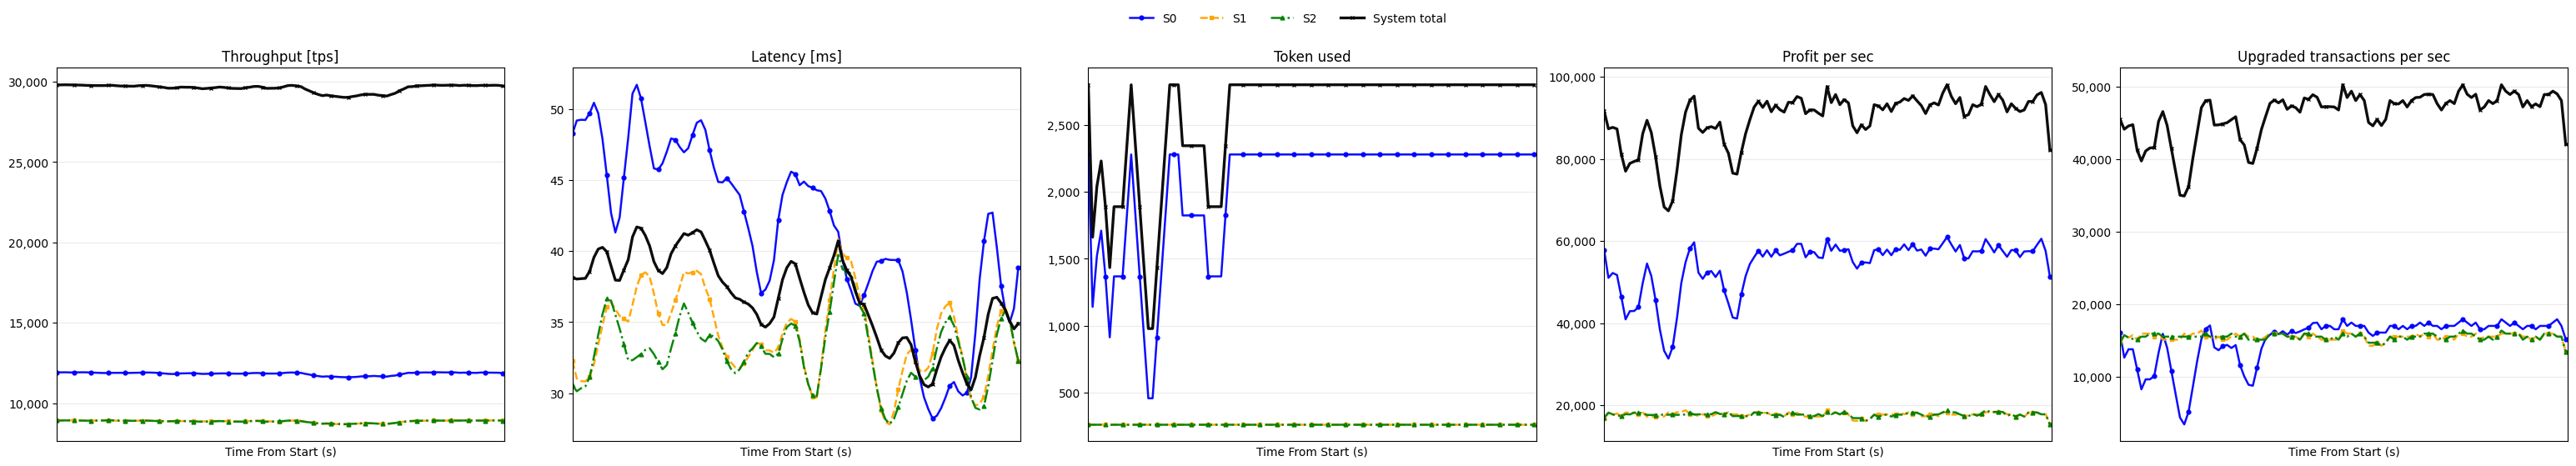

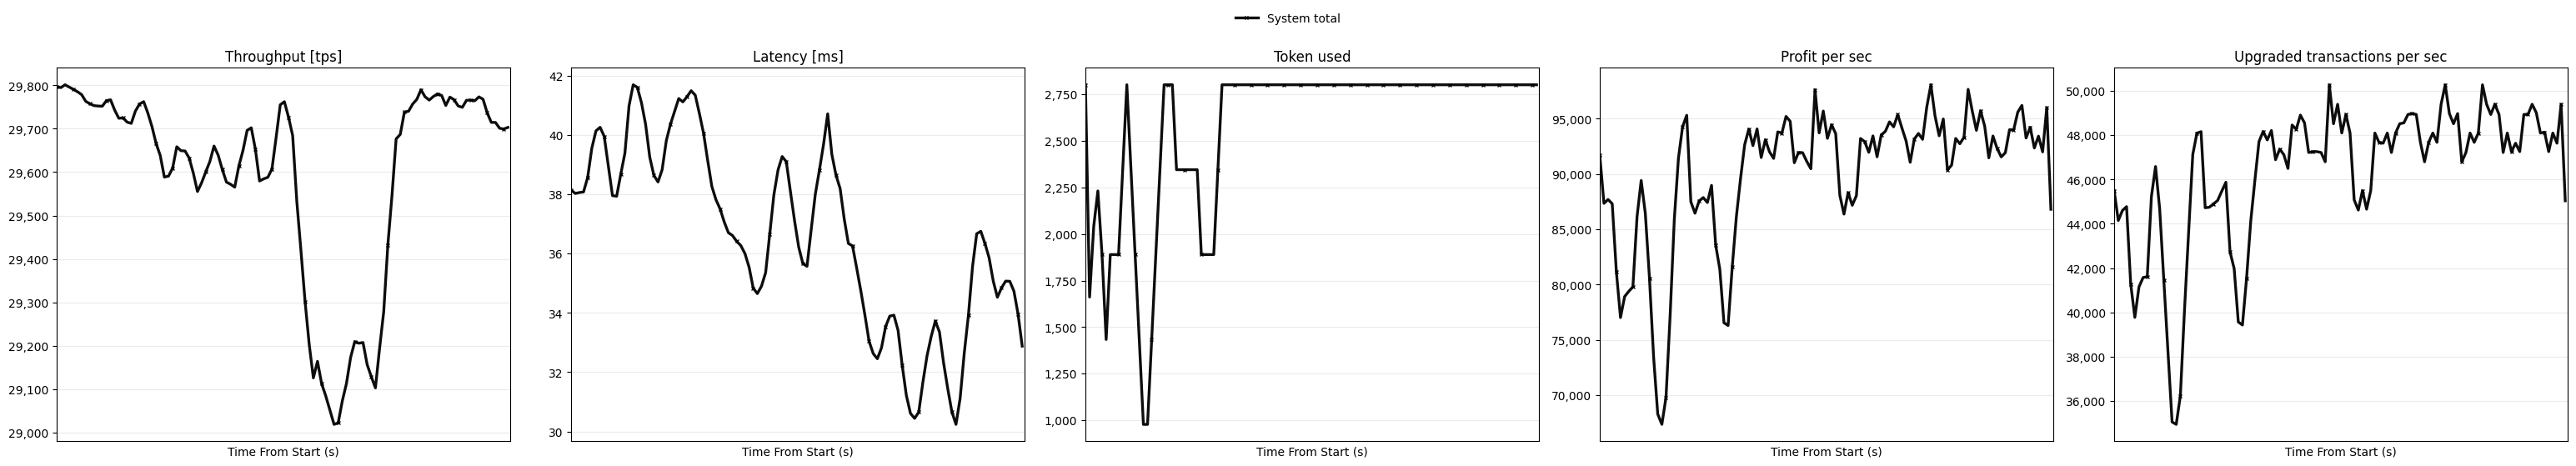

In [9]:
# 1x5 token-bucket + latency dashboard with timestamp-binned rendering and fixed phase markers
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Set the directory where CSV files are located
CSV_DIR = "."  # Change this if CSVs are in a different directory

# Server IDs - update to match the number of servers started in Servers.java
NUM_SERVERS = 3
SERVER_IDS = list(range(NUM_SERVERS))

COLORS = ['blue', 'orange', 'green', 'red', 'purple', 'brown']
LINESTYLES = ['-', '--', '-.', ':', (0, (3, 1, 1, 1)), (0, (5, 2))]
MARKERS = ['o', 's', '^', 'D', 'x', '*', 'v', 'P']


def _get_global_timestamp_bounds(server_frames):
    """Return (global_start_ts_ms, global_end_ts_ms) across all loaded server frames."""
    min_ts = None
    max_ts = None

    for df in server_frames.values():
        if "Timestamp" not in df.columns:
            continue
        t = pd.to_numeric(df["Timestamp"], errors="coerce").dropna()
        if t.empty:
            continue
        frame_min = float(t.min())
        frame_max = float(t.max())
        min_ts = frame_min if min_ts is None else min(min_ts, frame_min)
        max_ts = frame_max if max_ts is None else max(max_ts, frame_max)

    return min_ts, max_ts


def _load_system_latency_csv(filepath):
    """Load system_latency_<id>.csv in either header or headerless format."""
    df = pd.read_csv(filepath)
    if {"Timestamp", "SystemLatency"}.issubset(df.columns):
        return df

    # Fallback: some runs write headerless CSVs.
    return pd.read_csv(filepath, header=None, names=["Timestamp", "SystemLatency"] )


def _thousands(x, _):
    return f"{x:,.0f}"


def _build_binned_series(df, value_col, global_start_ts_ms, bin_ms=250, agg="median"):
    """Convert raw timestamp/value rows into fixed-width timestamp bins using the chosen aggregation."""
    t_ms = pd.to_numeric(df["Timestamp"], errors="coerce")
    y = pd.to_numeric(df[value_col], errors="coerce")
    s = pd.DataFrame({"ts_ms": t_ms, "value": y}).dropna(subset=["ts_ms", "value"])
    if s.empty:
        return s

    s["bin_ms"] = (((s["ts_ms"] - global_start_ts_ms) // float(bin_ms)) * float(bin_ms)).astype(float)

    if agg == "sum":
        out = s.groupby("bin_ms", as_index=False)["value"].sum()
    elif agg == "max":
        out = s.groupby("bin_ms", as_index=False)["value"].max()
    else:
        out = s.groupby("bin_ms", as_index=False)["value"].median()

    out["time_s"] = out["bin_ms"] / 1000.0
    return out[["time_s", "value"]]


def _add_moving_average(df, value_col="value"):
    """Add an adaptive moving average column for smoothing."""
    if df.empty:
        return df
    win = max(3, min(31, len(df) // 20))
    if win % 2 == 0:
        win += 1
    out = df.copy()
    out["ma"] = out[value_col].rolling(window=win, min_periods=1).mean()
    out["ma_window"] = win
    return out


def plot_tps_row_with_total_and_phases(
    server_ids=SERVER_IDS,
    phase_durations_s=None,
    phase_labels=None,
    bin_ms=250,
    warmup_exclude_s=10,
    end_exclude_s=0,
    phase_ticks_s=None,
    show_raw=False,
    show_total_raw=False,
    show_server_lines=True,
):
    """Plot in requested order with fixed phase ticks and marker-based line styling."""
    metric_specs = [
        ("CurrentTPS", "Throughput [tps]", "median", False),
        ("SystemLatency", "Latency [ms]", "median", False),
        ("TokensUsed", "Token used", "median", False),
        ("Profit", "Profit per sec", "sum", True),
        ("TransactionsUpgraded", "Upgraded transactions per sec", "sum", True),
    ]

    if phase_ticks_s is None:
        phase_ticks_s = [60, 120, 180, 240]

    server_frames = {}
    latency_frames = {}

    for sid in server_ids:
        tps_path = os.path.join(CSV_DIR, f"tps_{sid}.csv")
        if os.path.exists(tps_path):
            df_tps = pd.read_csv(tps_path)
            if "Timestamp" in df_tps.columns:
                server_frames[sid] = df_tps
            else:
                print(f"Server {sid} missing Timestamp column: {tps_path}")
        else:
            print(f"File not found: {tps_path}")

        latency_path = os.path.join(CSV_DIR, f"system_latency_{sid}.csv")
        if os.path.exists(latency_path):
            df_latency = _load_system_latency_csv(latency_path)
            if "Timestamp" in df_latency.columns and "SystemLatency" in df_latency.columns:
                latency_frames[sid] = df_latency
            else:
                print(f"Server {sid} missing Timestamp/SystemLatency columns: {latency_path}")
        else:
            print(f"File not found: {latency_path}")

    all_frames_for_time = {}
    all_frames_for_time.update(server_frames)
    all_frames_for_time.update({f"lat_{sid}": df for sid, df in latency_frames.items()})

    if not all_frames_for_time:
        print("No usable tps_<id>.csv or system_latency_<id>.csv files found for the selected servers.")
        return

    global_start_ts_ms, global_end_ts_ms = _get_global_timestamp_bounds(all_frames_for_time)
    if global_start_ts_ms is None or global_end_ts_ms is None:
        print("No valid Timestamp data found in selected CSV files.")
        return

    max_time_s = max(0.0, (global_end_ts_ms - global_start_ts_ms) / 1000.0)
    analysis_start_s = max(0.0, float(warmup_exclude_s))
    analysis_end_s = max(analysis_start_s, max_time_s - max(0.0, float(end_exclude_s)))
    if analysis_end_s <= analysis_start_s:
        print(
            f"Not enough data after warmup/end exclusion (start={analysis_start_s:.1f}s, end_cut={float(end_exclude_s):.1f}s)."
        )
        return

    boundary_positions = [t for t in phase_ticks_s if analysis_start_s <= t <= analysis_end_s]

    fig, axes = plt.subplots(1, len(metric_specs), figsize=(6.2 * len(metric_specs), 5.2), sharex=True)

    bin_sec = float(bin_ms) / 1000.0

    for ax_idx, (ax, (col, title, agg_mode, as_rate)) in enumerate(zip(axes, metric_specs)):
        total_df = pd.DataFrame()
        weight_df = pd.DataFrame()

        metric_frames = latency_frames if col == "SystemLatency" else server_frames

        for i, sid in enumerate(server_ids):
            if sid not in metric_frames:
                continue
            df = metric_frames[sid]
            if col not in df.columns:
                print(f"Server {sid} missing column: {col}")
                continue

            binned = _build_binned_series(df, col, global_start_ts_ms, bin_ms=bin_ms, agg=agg_mode)
            if binned.empty:
                continue
            if as_rate and bin_sec > 0:
                binned["value"] = binned["value"] / bin_sec

            binned = binned[(binned["time_s"] >= analysis_start_s) & (binned["time_s"] <= analysis_end_s)]
            if binned.empty:
                continue
            binned = _add_moving_average(binned, value_col="value")

            color = COLORS[i % len(COLORS)]
            linestyle = LINESTYLES[i % len(LINESTYLES)]
            marker = MARKERS[i % len(MARKERS)]
            markevery = max(1, len(binned) // 24)

            if show_server_lines and show_raw:
                ax.plot(
                    binned["time_s"],
                    binned["value"],
                    color=color,
                    linestyle=linestyle,
                    linewidth=0.8,
                    alpha=0.25,
                    marker=marker,
                    markersize=3,
                    markevery=markevery,
                    label=f"S{sid} raw",
                )

            if show_server_lines:
                ax.plot(
                    binned["time_s"],
                    binned["ma"],
                    color=color,
                    linestyle=linestyle,
                    linewidth=1.8,
                    alpha=0.95,
                    marker=marker,
                    markersize=3.5,
                    markevery=markevery,
                    label=f"S{sid}",
                )

            tmp = binned.rename(columns={"value": f"S{sid}"}).drop_duplicates(subset=["time_s"]).set_index("time_s")
            total_df = total_df.join(tmp[[f"S{sid}"]], how="outer") if not total_df.empty else tmp[[f"S{sid}"]]

            if col == "SystemLatency" and sid in server_frames and "CurrentTPS" in server_frames[sid].columns:
                tps_binned = _build_binned_series(server_frames[sid], "CurrentTPS", global_start_ts_ms, bin_ms=bin_ms, agg="median")
                if not tps_binned.empty:
                    tps_binned = tps_binned[(tps_binned["time_s"] >= analysis_start_s) & (tps_binned["time_s"] <= analysis_end_s)]
                    if not tps_binned.empty:
                        wtmp = tps_binned.rename(columns={"value": f"W{sid}"}).drop_duplicates(subset=["time_s"]).set_index("time_s")
                        weight_df = weight_df.join(wtmp[[f"W{sid}"]], how="outer") if not weight_df.empty else wtmp[[f"W{sid}"]]

        if not total_df.empty:
            total_df = total_df.sort_index()
            if col == "SystemLatency":
                total_series = pd.Series(index=total_df.index, dtype="float64")
                if not weight_df.empty:
                    weighted_num = pd.Series(0.0, index=total_df.index)
                    weighted_den = pd.Series(0.0, index=total_df.index)
                    for lat_col in total_df.columns:
                        sid_part = lat_col[1:] if lat_col.startswith("S") else None
                        w_col = f"W{sid_part}" if sid_part is not None else None
                        if w_col is None or w_col not in weight_df.columns:
                            continue
                        lat_s = pd.to_numeric(total_df[lat_col], errors="coerce")
                        w_s = pd.to_numeric(weight_df[w_col].reindex(total_df.index), errors="coerce").clip(lower=0)
                        valid = lat_s.notna() & w_s.notna() & (w_s > 0)
                        weighted_num = weighted_num.add((lat_s.where(valid, 0.0) * w_s.where(valid, 0.0)), fill_value=0.0)
                        weighted_den = weighted_den.add(w_s.where(valid, 0.0), fill_value=0.0)
                    total_series = weighted_num.div(weighted_den.where(weighted_den > 0)).where(weighted_den > 0)

                if total_series.dropna().empty:
                    total_series = total_df.mean(axis=1, skipna=True)
            else:
                total_series = total_df.fillna(0).sum(axis=1)

            total_plot = pd.DataFrame({"time_s": total_series.index, "value": total_series.values})
            total_plot = total_plot[(total_plot["time_s"] >= analysis_start_s) & (total_plot["time_s"] <= analysis_end_s)]
            if not total_plot.empty:
                total_plot = _add_moving_average(total_plot, value_col="value")
                total_marker = MARKERS[(len(server_ids) + 1) % len(MARKERS)]
                total_markevery = max(1, len(total_plot) // 24)

                if show_total_raw:
                    ax.plot(
                        total_plot["time_s"],
                        total_plot["value"],
                        color="black",
                        linewidth=1.0,
                        alpha=0.25,
                        marker=total_marker,
                        markersize=3,
                        markevery=total_markevery,
                        label="System raw"
                    )
                ax.plot(
                    total_plot["time_s"],
                    total_plot["ma"],
                    color="black",
                    linewidth=2.4,
                    alpha=0.95,
                    marker=total_marker,
                    markersize=3.5,
                    markevery=total_markevery,
                    label="System total"
                )

        for b in boundary_positions:
            ax.axvline(b, color="gray", linestyle="--", linewidth=1, alpha=0.65)

        ax.set_title(title)
        ax.set_xlabel("Time From Start (s)")
        ax.set_xlim(left=analysis_start_s, right=analysis_end_s)
        ax.set_xticks(boundary_positions)
        ax.set_xticklabels([str(int(x)) for x in boundary_positions])
        ax.grid(True, alpha=0.25)
        ax.yaxis.set_major_formatter(FuncFormatter(_thousands))

    unique = {}
    for ax in axes:
        handles, labels = ax.get_legend_handles_labels()
        for h, l in zip(handles, labels):
            if l not in unique:
                unique[l] = h

    fig.legend(
        list(unique.values()),
        list(unique.keys()),
        loc="upper center",
        ncol=min(8, len(unique)),
        bbox_to_anchor=(0.5, 1.08),
        frameon=False,
    )

    plt.tight_layout()
    plt.show()


# Existing full view
plot_tps_row_with_total_and_phases(
    bin_ms=250,
    warmup_exclude_s=10,
    end_exclude_s=0,
    phase_ticks_s=[60, 120, 180, 240],
)

# Separate set: only system total lines
plot_tps_row_with_total_and_phases(
    bin_ms=250,
    warmup_exclude_s=10,
    end_exclude_s=0,
    phase_ticks_s=[60, 120, 180, 240],
    show_server_lines=False,
    show_raw=False,
    show_total_raw=False,
)

In [ ]:
lumns=phase_order)
        with pd.option_context('display.max_columns', None, 'display.width', 200):
            print(sample_pivot.sort_index())


# Ignore first 10s warmup, then apply explicit phase durations in seconds.
plot_tps_row_with_total_and_phases(
    phase_durations_s=[30,30,30,30],
    phase_labels=["Light", "Light", "Light", "Light"],
    bin_ms=250,
    warmup_exclude_s=10,
    end_exclude_s=10,
)

In [12]:
# Phase boundary continuity + gap diagnostics
import os
import pandas as pd

CSV_DIR = "."
SERVER_IDS = [0, 1, 2]

# Match your plotting parameters
warmup_exclude_s = 10
end_exclude_s = 5
phase_durations_s = [60, 60, 60, 60]


def _load_ts(path):
    if not os.path.exists(path):
        return pd.Series(dtype="float64")
    df = pd.read_csv(path)
    if "Timestamp" not in df.columns:
        return pd.Series(dtype="float64")
    ts = pd.to_numeric(df["Timestamp"], errors="coerce").dropna().sort_values().reset_index(drop=True)
    return ts


all_ts = {}
for sid in SERVER_IDS:
    path = os.path.join(CSV_DIR, f"tps_{sid}.csv")
    ts = _load_ts(path)
    if not ts.empty:
        all_ts[sid] = ts

if not all_ts:
    print("No tps_<id>.csv with Timestamp found for selected servers.")
else:
    global_start = min(ts.iloc[0] for ts in all_ts.values())
    global_end = max(ts.iloc[-1] for ts in all_ts.values())

    max_time_s = (global_end - global_start) / 1000.0
    analysis_start_s = max(0.0, float(warmup_exclude_s))
    analysis_end_s = max(analysis_start_s, max_time_s - max(0.0, float(end_exclude_s)))

    # Build phase edges exactly like the plotting function (durations mode)
    phase_edges = [analysis_start_s]
    cur = analysis_start_s
    for d in phase_durations_s:
        d = float(d)
        if d <= 0:
            continue
        cur += d
        if cur >= analysis_end_s:
            break
        phase_edges.append(cur)
    phase_edges.append(analysis_end_s)

    print("Analysis window (s):", round(analysis_start_s, 3), "->", round(analysis_end_s, 3))
    print("Phase edges (s):", [round(x, 3) for x in phase_edges])

    # 1) Theoretical continuity check: edges are contiguous by construction
    contiguous = True
    for i in range(len(phase_edges) - 2):
        left_end = phase_edges[i + 1]
        right_start = phase_edges[i + 1]
        if abs(left_end - right_start) > 1e-9:
            contiguous = False
            break
    print("Theoretical phase boundary continuity:", "PASS" if contiguous else "FAIL")

    # 2) Data continuity around each boundary per server
    print("\nObserved timestamp gap around each boundary (ms):")
    for b_idx, b_s in enumerate(phase_edges[1:-1], start=1):
        b_ts = global_start + b_s * 1000.0
        print(f"Boundary {b_idx} at t={b_s:.3f}s")

        for sid in sorted(all_ts.keys()):
            ts = all_ts[sid]
            left = ts[ts <= b_ts]
            right = ts[ts >= b_ts]

            prev_ts = float(left.iloc[-1]) if not left.empty else None
            next_ts = float(right.iloc[0]) if not right.empty else None

            if prev_ts is None or next_ts is None:
                print(f"  S{sid}: insufficient data around boundary")
                continue

            gap_ms = next_ts - prev_ts
            print(
                f"  S{sid}: prev={prev_ts:.0f}, next={next_ts:.0f}, "
                f"cross-boundary gap={gap_ms:.1f} ms"
            )

Analysis window (s): 10.0 -> 117.021
Phase edges (s): [10.0, 70.0, np.float64(117.021)]
Theoretical phase boundary continuity: PASS

Observed timestamp gap around each boundary (ms):
Boundary 1 at t=70.000s
  S0: prev=1776191664360, next=1776191664383, cross-boundary gap=23.0 ms
  S1: prev=1776191664357, next=1776191664380, cross-boundary gap=23.0 ms
  S2: prev=1776191664343, next=1776191664387, cross-boundary gap=44.0 ms


In [39]:
# Average TPS/Tokens/Profit/SystemLatency for experiment window (server-wise + whole system)
import os
import pandas as pd

CSV_DIR = "."
NUM_SERVERS = 3  # Change if needed
SERVER_IDS = list(range(NUM_SERVERS))
BIN_MS = 250  # Bin width for system-wide time alignment
WARMUP_EXCLUDE_S = 10  # Exclude first N seconds from global start


def _load_tps_csv(path):
    if not os.path.exists(path):
        return pd.DataFrame()
    df = pd.read_csv(path)
    required = {"Timestamp", "CurrentTPS", "TokensUsed", "Profit"}
    if not required.issubset(df.columns):
        print(f"Skipping {path}: missing one of {sorted(required)}")
        return pd.DataFrame()
    return df


def _load_system_latency_csv(path):
    if not os.path.exists(path):
        return pd.DataFrame()
    df = pd.read_csv(path)
    if {"Timestamp", "SystemLatency"}.issubset(df.columns):
        return df
    # Some runs are headerless
    return pd.read_csv(path, header=None, names=["Timestamp", "SystemLatency"])


def _to_numeric(df, cols):
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    return out


def _build_binned_metric(df, value_col, global_start_ts_ms, bin_ms=250, agg="median", analysis_start_s=0.0):
    if df.empty or value_col not in df.columns:
        return pd.DataFrame(columns=["bin_ms", value_col])
    t = pd.to_numeric(df["Timestamp"], errors="coerce")
    v = pd.to_numeric(df[value_col], errors="coerce")
    s = pd.DataFrame({"Timestamp": t, value_col: v}).dropna()
    if s.empty:
        return pd.DataFrame(columns=["bin_ms", value_col])

    s["time_s"] = (s["Timestamp"] - float(global_start_ts_ms)) / 1000.0
    s = s[s["time_s"] >= float(analysis_start_s)]
    if s.empty:
        return pd.DataFrame(columns=["bin_ms", value_col])

    s["bin_ms"] = (((s["Timestamp"] - global_start_ts_ms) // float(bin_ms)) * float(bin_ms)).astype(float)
    if agg == "sum":
        out = s.groupby("bin_ms", as_index=False)[value_col].sum()
    elif agg == "max":
        out = s.groupby("bin_ms", as_index=False)[value_col].max()
    else:
        out = s.groupby("bin_ms", as_index=False)[value_col].median()
    return out


def compute_experiment_averages(server_ids=SERVER_IDS, bin_ms=BIN_MS, warmup_exclude_s=WARMUP_EXCLUDE_S):
    per_server_rows = []
    tps_frames = {}
    latency_frames = {}
    min_ts, max_ts = None, None

    # 1) Load CSVs first
    for sid in server_ids:
        tps_path = os.path.join(CSV_DIR, f"tps_{sid}.csv")
        lat_path = os.path.join(CSV_DIR, f"system_latency_{sid}.csv")
        tps_df = _to_numeric(
            _load_tps_csv(tps_path),
            ["Timestamp", "CurrentTPS", "TokensUsed", "Profit", "TransactionsUpgraded"],
        )
        lat_df = _to_numeric(_load_system_latency_csv(lat_path), ["Timestamp", "SystemLatency"])

        if not tps_df.empty:
            tps_frames[sid] = tps_df
            ts = tps_df["Timestamp"].dropna()
            if not ts.empty:
                cur_min, cur_max = float(ts.min()), float(ts.max())
                min_ts = cur_min if min_ts is None else min(min_ts, cur_min)
                max_ts = cur_max if max_ts is None else max(max_ts, cur_max)

        if not lat_df.empty and {"Timestamp", "SystemLatency"}.issubset(lat_df.columns):
            latency_frames[sid] = lat_df
            ts = lat_df["Timestamp"].dropna()
            if not ts.empty:
                cur_min, cur_max = float(ts.min()), float(ts.max())
                min_ts = cur_min if min_ts is None else min(min_ts, cur_min)
                max_ts = cur_max if max_ts is None else max(max_ts, cur_max)

    if min_ts is None or max_ts is None:
        print("No valid Timestamp data found.")
        return pd.DataFrame(), pd.DataFrame()

    analysis_start_ts = min_ts + float(warmup_exclude_s) * 1000.0

    # 2) Server-wise means after warmup
    for sid in server_ids:
        tps_df = tps_frames.get(sid, pd.DataFrame())
        lat_df = latency_frames.get(sid, pd.DataFrame())

        if not tps_df.empty:
            tps_df = tps_df[pd.to_numeric(tps_df["Timestamp"], errors="coerce") >= analysis_start_ts]
        if not lat_df.empty:
            lat_df = lat_df[pd.to_numeric(lat_df["Timestamp"], errors="coerce") >= analysis_start_ts]

        per_server_rows.append({
            "Server": sid,
            "AvgCurrentTPS": tps_df["CurrentTPS"].mean() if "CurrentTPS" in tps_df.columns else float("nan"),
            "AvgTokensUsed": tps_df["TokensUsed"].mean() if "TokensUsed" in tps_df.columns else float("nan"),
            "AvgProfit": tps_df["Profit"].mean() if "Profit" in tps_df.columns else float("nan"),
            "AvgSystemLatency_ms": lat_df["SystemLatency"].mean() if "SystemLatency" in lat_df.columns else float("nan"),
            "TotalTransactionsUpgraded": tps_df["TransactionsUpgraded"].sum() if "TransactionsUpgraded" in tps_df.columns else float("nan"),
            "TPSSamples": int(tps_df["CurrentTPS"].notna().sum()) if "CurrentTPS" in tps_df.columns else 0,
            "LatencySamples": int(lat_df["SystemLatency"].notna().sum()) if "SystemLatency" in lat_df.columns else 0,
        })

    per_server_df = pd.DataFrame(per_server_rows).sort_values("Server").reset_index(drop=True)

    # 3) Whole-system averages via timestamp bins after warmup
    system_cols = ["CurrentTPS", "TokensUsed", "Profit"]
    system_totals = {col: pd.DataFrame() for col in system_cols}

    for sid, df in tps_frames.items():
        for col in system_cols:
            b = _build_binned_metric(
                df,
                col,
                min_ts,
                bin_ms=bin_ms,
                agg="median",
                analysis_start_s=float(warmup_exclude_s),
            )
            if b.empty:
                continue
            b = b.rename(columns={col: f"S{sid}_{col}"}).set_index("bin_ms")[[f"S{sid}_{col}"]]
            system_totals[col] = system_totals[col].join(b, how="outer") if not system_totals[col].empty else b

    system_summary = {}
    for col in system_cols:
        dfc = system_totals[col]
        if dfc.empty:
            system_summary[f"SystemAvg{col}"] = float("nan")
            continue
        system_series = dfc.fillna(0).sum(axis=1)
        system_summary[f"SystemAvg{col}"] = float(system_series.mean())

    # Total transactions upgraded across all servers after warmup
    total_upgraded = 0.0
    has_upgraded = False
    for df in tps_frames.values():
        filtered = df[pd.to_numeric(df["Timestamp"], errors="coerce") >= analysis_start_ts]
        if "TransactionsUpgraded" in filtered.columns:
            total_upgraded += pd.to_numeric(filtered["TransactionsUpgraded"], errors="coerce").fillna(0).sum()
            has_upgraded = True
    system_summary["SystemTotalTransactionsUpgraded"] = float(total_upgraded) if has_upgraded else float("nan")

    # 4) Whole-system latency average (two ways), after warmup
    all_lat_samples = []
    for df in latency_frames.values():
        ldf = df[pd.to_numeric(df["Timestamp"], errors="coerce") >= analysis_start_ts]
        all_lat_samples.append(pd.to_numeric(ldf["SystemLatency"], errors="coerce").dropna())

    if all_lat_samples and any(not s.empty for s in all_lat_samples):
        all_lat = pd.concat(all_lat_samples, ignore_index=True)
        system_summary["SystemAvgLatency_ms_unweighted"] = float(all_lat.mean())
    else:
        system_summary["SystemAvgLatency_ms_unweighted"] = float("nan")

    lat_matrix = pd.DataFrame()
    w_matrix = pd.DataFrame()

    for sid, ldf in latency_frames.items():
        lb = _build_binned_metric(
            ldf,
            "SystemLatency",
            min_ts,
            bin_ms=bin_ms,
            agg="median",
            analysis_start_s=float(warmup_exclude_s),
        )
        if lb.empty:
            continue
        lb = lb.rename(columns={"SystemLatency": f"L{sid}"}).set_index("bin_ms")[[f"L{sid}"]]
        lat_matrix = lat_matrix.join(lb, how="outer") if not lat_matrix.empty else lb

        if sid in tps_frames:
            wb = _build_binned_metric(
                tps_frames[sid],
                "CurrentTPS",
                min_ts,
                bin_ms=bin_ms,
                agg="median",
                analysis_start_s=float(warmup_exclude_s),
            )
            if not wb.empty:
                wb = wb.rename(columns={"CurrentTPS": f"W{sid}"}).set_index("bin_ms")[[f"W{sid}"]]
                w_matrix = w_matrix.join(wb, how="outer") if not w_matrix.empty else wb

    weighted_latency_avg = float("nan")
    if not lat_matrix.empty and not w_matrix.empty:
        idx = lat_matrix.index.union(w_matrix.index)
        lat_matrix = lat_matrix.reindex(idx)
        w_matrix = w_matrix.reindex(idx)

        num = pd.Series(0.0, index=idx)
        den = pd.Series(0.0, index=idx)
        for lcol in lat_matrix.columns:
            sid = lcol[1:] if lcol.startswith("L") else None
            wcol = f"W{sid}" if sid is not None else None
            if wcol not in w_matrix.columns:
                continue
            lat_s = pd.to_numeric(lat_matrix[lcol], errors="coerce")
            w_s = pd.to_numeric(w_matrix[wcol], errors="coerce").clip(lower=0)
            valid = lat_s.notna() & w_s.notna() & (w_s > 0)
            num = num.add(lat_s.where(valid, 0.0) * w_s.where(valid, 0.0), fill_value=0.0)
            den = den.add(w_s.where(valid, 0.0), fill_value=0.0)

        lat_weighted_series = num.div(den.where(den > 0)).where(den > 0)
        if not lat_weighted_series.dropna().empty:
            weighted_latency_avg = float(lat_weighted_series.mean())

    system_summary["SystemAvgLatency_ms_tps_weighted"] = weighted_latency_avg
    system_summary["ServersIncluded"] = len(server_ids)
    system_summary["WarmupExcluded_s"] = float(warmup_exclude_s)
    system_summary["ExperimentDuration_s"] = round((max_ts - min_ts) / 1000.0, 2)
    system_summary["BinMs"] = bin_ms

    system_df = pd.DataFrame([system_summary])
    return per_server_df, system_df


server_averages, system_averages = compute_experiment_averages(
    server_ids=SERVER_IDS,
    bin_ms=BIN_MS,
    warmup_exclude_s=WARMUP_EXCLUDE_S,
)

print("\nServer-wise averages (after warmup exclusion):")
with pd.option_context("display.max_columns", None, "display.width", 200):
    print(server_averages.round(3))

print("\nWhole-system averages (after warmup exclusion):")
with pd.option_context("display.max_columns", None, "display.width", 200):
    print(system_averages.round(3))

# Optional: save results
server_averages.to_csv("server_wise_experiment_averages.csv", index=False)
system_averages.to_csv("system_experiment_averages.csv", index=False)
print("\nSaved: server_wise_experiment_averages.csv, system_experiment_averages.csv")


Server-wise averages (after warmup exclusion):
   Server  AvgCurrentTPS  AvgTokensUsed  AvgProfit  AvgSystemLatency_ms  TotalTransactionsUpgraded  TPSSamples  LatencySamples
0       0       8932.343        493.645    602.721               26.939                    1118016        3622            3622
1       1      11915.060       1689.462   1127.745               34.349                     515772        3515            3515
2       2       8931.217        482.190    604.882               28.217                     997439        3612            3612

Whole-system averages (after warmup exclusion):
   SystemAvgCurrentTPS  SystemAvgTokensUsed  SystemAvgProfit  SystemTotalTransactionsUpgraded  SystemAvgLatency_ms_unweighted  SystemAvgLatency_ms_tps_weighted  ServersIncluded  WarmupExcluded_s  \
0            29778.308             2604.489         2296.231                        2631227.0                          29.792                            30.424                3              10.0   

In [4]:
# Copy-paste friendly report: one metric per line

import pandas as pd

def _fmt(v, digits=3):
    if pd.isna(v):
        return "NA"
    return f"{float(v):,.{digits}f}"

# Recompute if needed
if "server_averages" not in globals() or "system_averages" not in globals():
    server_averages, system_averages = compute_experiment_averages(
        server_ids=SERVER_IDS,
        bin_ms=BIN_MS,
        warmup_exclude_s=WARMUP_EXCLUDE_S,
    )

print("=" * 72)
print("EXPERIMENT AVERAGE REPORT")
print("=" * 72)

if not system_averages.empty:
    s = system_averages.iloc[0]
    print("\nWHOLE SYSTEM (after warmup exclusion)")
    print(f"Warmup Excluded (s): {_fmt(s.get('WarmupExcluded_s'), 2)}")
    print(f"Average CurrentTPS: {_fmt(s.get('SystemAvgCurrentTPS'))}")
    print(f"Average TokensUsed: {_fmt(s.get('SystemAvgTokensUsed'))}")
    print(f"Average Profit: {_fmt(s.get('SystemAvgProfit'))}")
    print(f"Total TransactionsUpgraded: {_fmt(s.get('SystemTotalTransactionsUpgraded'), 0)}")
    print(f"Average SystemLatency (unweighted ms): {_fmt(s.get('SystemAvgLatency_ms_unweighted'))}")
    print(f"Average SystemLatency (TPS-weighted ms): {_fmt(s.get('SystemAvgLatency_ms_tps_weighted'))}")
    print(f"Servers Included: {int(s.get('ServersIncluded')) if pd.notna(s.get('ServersIncluded')) else 'NA'}")
    print(f"Experiment Duration (s): {_fmt(s.get('ExperimentDuration_s'), 2)}")
else:
    print("\nWHOLE SYSTEM (after warmup exclusion)")
    print("No system-level data available.")

# print("\n" + "-" * 72)
# print("SERVER-WISE (after warmup exclusion)")
# print("-" * 72)

# if server_averages.empty:
#     print("No server-level data available.")
# else:
#     for _, row in server_averages.sort_values("Server").iterrows():
#         sid = int(row["Server"]) if pd.notna(row["Server"]) else "NA"
#         print(f"\nServer {sid}")
#         print(f"Average CurrentTPS: {_fmt(row.get('AvgCurrentTPS'))}")
#         print(f"Average TokensUsed: {_fmt(row.get('AvgTokensUsed'))}")
#         print(f"Average Profit: {_fmt(row.get('AvgProfit'))}")
#         print(f"Total TransactionsUpgraded: {_fmt(row.get('TotalTransactionsUpgraded'), 0)}")
#         print(f"Average SystemLatency (ms): {_fmt(row.get('AvgSystemLatency_ms'))}")
#         print(f"TPS Samples: {int(row.get('TPSSamples')) if pd.notna(row.get('TPSSamples')) else 'NA'}")
#         print(f"Latency Samples: {int(row.get('LatencySamples')) if pd.notna(row.get('LatencySamples')) else 'NA'}")

# print("\n" + "=" * 72)

EXPERIMENT AVERAGE REPORT

WHOLE SYSTEM (after warmup exclusion)
Warmup Excluded (s): 10.00
Average CurrentTPS: 32,223.065
Average TokensUsed: 12,396.879
Average Profit: 2,654.129
Total TransactionsUpgraded: 0
Average SystemLatency (unweighted ms): 181.278
Average SystemLatency (TPS-weighted ms): 724.993
Servers Included: 3
Experiment Duration (s): 239.96


In [1]:
# Phase-wise and overall system averages (excluding warmup)
import os
import pandas as pd

CSV_DIR = "."
NUM_SERVERS = 3
SERVER_IDS = list(range(NUM_SERVERS))

# Match your experiment setup
WARMUP_EXCLUDE_S = 10
PHASE_DURATIONS_S = [30, 30, 30, 30]
PHASE_LABELS = ["Light", "Medium", "Heavy", "Light"]
BIN_MS = 250
PHASES_START_AFTER_WARMUP = True  # True => phase1 is [warmup, warmup+duration], e.g., 10s->70s


def _load_tps_phase_csv(path):
    if not os.path.exists(path):
        return pd.DataFrame()
    df = pd.read_csv(path)
    needed = {"Timestamp", "CurrentTPS", "Profit", "TokensUsed", "TransactionsUpgraded"}
    if not needed.issubset(df.columns):
        print(f"Skipping {path}: missing one of {sorted(needed)}")
        return pd.DataFrame()
    return df


def _load_latency_phase_csv(path):
    if not os.path.exists(path):
        return pd.DataFrame()
    df = pd.read_csv(path)
    if {"Timestamp", "SystemLatency"}.issubset(df.columns):
        return df
    return pd.read_csv(path, header=None, names=["Timestamp", "SystemLatency"])


def _to_num(df, cols):
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = pd.to_numeric(out[c], errors="coerce")
    return out


def _global_bounds(frames):
    min_ts, max_ts = None, None
    for df in frames.values():
        if "Timestamp" not in df.columns:
            continue
        ts = pd.to_numeric(df["Timestamp"], errors="coerce").dropna()
        if ts.empty:
            continue
        cur_min, cur_max = float(ts.min()), float(ts.max())
        min_ts = cur_min if min_ts is None else min(min_ts, cur_min)
        max_ts = cur_max if max_ts is None else max(max_ts, cur_max)
    return min_ts, max_ts


def _build_binned(df, value_col, global_start_ts_ms, bin_ms=250, agg="median"):
    if df.empty or value_col not in df.columns:
        return pd.DataFrame(columns=["time_s", "value"])
    ts = pd.to_numeric(df["Timestamp"], errors="coerce")
    val = pd.to_numeric(df[value_col], errors="coerce")
    s = pd.DataFrame({"ts": ts, "value": val}).dropna()
    if s.empty:
        return pd.DataFrame(columns=["time_s", "value"])
    s["bin_ms"] = (((s["ts"] - global_start_ts_ms) // float(bin_ms)) * float(bin_ms)).astype(float)
    if agg == "sum":
        out = s.groupby("bin_ms", as_index=False)["value"].sum()
    elif agg == "max":
        out = s.groupby("bin_ms", as_index=False)["value"].max()
    else:
        out = s.groupby("bin_ms", as_index=False)["value"].median()
    out["time_s"] = out["bin_ms"] / 1000.0
    return out[["time_s", "value"]]


def _phase_windows(analysis_start_s, analysis_end_s, durations_s, labels, phases_start_after_warmup=True):
    windows = []
    raw_start = float(analysis_start_s) if phases_start_after_warmup else 0.0
    for i, d in enumerate(durations_s):
        d = float(d)
        if d <= 0:
            continue

        raw_end = raw_start + d
        start = max(raw_start, float(analysis_start_s))
        end = min(raw_end, float(analysis_end_s))

        if end > start:
            label = labels[i] if i < len(labels) else f"Phase{i+1}"
            windows.append((label, start, end))

        raw_start = raw_end
        if raw_start >= analysis_end_s:
            break
    return windows


def compute_phase_and_overall_metrics(
    server_ids=SERVER_IDS,
    warmup_exclude_s=WARMUP_EXCLUDE_S,
    phase_durations_s=PHASE_DURATIONS_S,
    phase_labels=PHASE_LABELS,
    bin_ms=BIN_MS,
    include_server_breakdown=False,
    save_csv=True,
    phases_start_after_warmup=PHASES_START_AFTER_WARMUP,
    ):
    tps_frames = {}
    lat_frames = {}

    for sid in server_ids:
        tps = _to_num(_load_tps_phase_csv(os.path.join(CSV_DIR, f"tps_{sid}.csv")),
                      ["Timestamp", "CurrentTPS", "Profit", "TokensUsed", "TransactionsUpgraded"])
        lat = _to_num(_load_latency_phase_csv(os.path.join(CSV_DIR, f"system_latency_{sid}.csv")),
                      ["Timestamp", "SystemLatency"])
        if not tps.empty:
            tps_frames[sid] = tps
        if not lat.empty and {"Timestamp", "SystemLatency"}.issubset(lat.columns):
            lat_frames[sid] = lat

    all_time_frames = {}
    all_time_frames.update(tps_frames)
    all_time_frames.update({f"lat_{sid}": df for sid, df in lat_frames.items()})
    global_start_ts, global_end_ts = _global_bounds(all_time_frames)
    if global_start_ts is None or global_end_ts is None:
        print("No valid timestamp data found.")
        return pd.DataFrame(), pd.DataFrame()

    max_time_s = max(0.0, (global_end_ts - global_start_ts) / 1000.0)
    analysis_start_s = max(0.0, float(warmup_exclude_s))
    analysis_end_s = max(analysis_start_s, max_time_s)
    if analysis_end_s <= analysis_start_s:
        print("No analysis window after warmup exclusion.")
        return pd.DataFrame(), pd.DataFrame()

    phases = _phase_windows(
        analysis_start_s,
        analysis_end_s,
        phase_durations_s,
        phase_labels,
        phases_start_after_warmup=phases_start_after_warmup,
    )
    windows = phases + [("Overall", analysis_start_s, analysis_end_s)]

    # Build system time-series per bin
    tps_matrix = pd.DataFrame()
    profit_matrix = pd.DataFrame()
    tokens_matrix = pd.DataFrame()
    upgrades_matrix = pd.DataFrame()
    latency_matrix = pd.DataFrame()
    weight_matrix = pd.DataFrame()

    for sid, tdf in tps_frames.items():
        btps = _build_binned(tdf, "CurrentTPS", global_start_ts, bin_ms=bin_ms, agg="median")
        bprof = _build_binned(tdf, "Profit", global_start_ts, bin_ms=bin_ms, agg="sum")
        btok = _build_binned(tdf, "TokensUsed", global_start_ts, bin_ms=bin_ms, agg="sum")
        bup = _build_binned(tdf, "TransactionsUpgraded", global_start_ts, bin_ms=bin_ms, agg="sum")

        if not btps.empty:
            tps_matrix = tps_matrix.join(
                btps.rename(columns={"value": f"S{sid}"}).set_index("time_s")[[f"S{sid}"]],
                how="outer",
            ) if not tps_matrix.empty else btps.rename(columns={"value": f"S{sid}"}).set_index("time_s")[[f"S{sid}"]]

            weight_matrix = weight_matrix.join(
                btps.rename(columns={"value": f"W{sid}"}).set_index("time_s")[[f"W{sid}"]],
                how="outer",
            ) if not weight_matrix.empty else btps.rename(columns={"value": f"W{sid}"}).set_index("time_s")[[f"W{sid}"]]

        if not bprof.empty:
            profit_matrix = profit_matrix.join(
                bprof.rename(columns={"value": f"S{sid}"}).set_index("time_s")[[f"S{sid}"]],
                how="outer",
            ) if not profit_matrix.empty else bprof.rename(columns={"value": f"S{sid}"}).set_index("time_s")[[f"S{sid}"]]

        if not btok.empty:
            tokens_matrix = tokens_matrix.join(
                btok.rename(columns={"value": f"S{sid}"}).set_index("time_s")[[f"S{sid}"]],
                how="outer",
            ) if not tokens_matrix.empty else btok.rename(columns={"value": f"S{sid}"}).set_index("time_s")[[f"S{sid}"]]

        if not bup.empty:
            upgrades_matrix = upgrades_matrix.join(
                bup.rename(columns={"value": f"S{sid}"}).set_index("time_s")[[f"S{sid}"]],
                how="outer",
            ) if not upgrades_matrix.empty else bup.rename(columns={"value": f"S{sid}"}).set_index("time_s")[[f"S{sid}"]]

    for sid, ldf in lat_frames.items():
        blat = _build_binned(ldf, "SystemLatency", global_start_ts, bin_ms=bin_ms, agg="median")
        if not blat.empty:
            latency_matrix = latency_matrix.join(
                blat.rename(columns={"value": f"L{sid}"}).set_index("time_s")[[f"L{sid}"]],
                how="outer",
            ) if not latency_matrix.empty else blat.rename(columns={"value": f"L{sid}"}).set_index("time_s")[[f"L{sid}"]]

    # Build TPS-weighted system latency series
    system_latency = pd.Series(dtype="float64")
    if not latency_matrix.empty and not weight_matrix.empty:
        idx = latency_matrix.index.union(weight_matrix.index)
        lat = latency_matrix.reindex(idx)
        wt = weight_matrix.reindex(idx)
        num = pd.Series(0.0, index=idx)
        den = pd.Series(0.0, index=idx)
        for lcol in lat.columns:
            sid = lcol[1:] if lcol.startswith("L") else None
            wcol = f"W{sid}" if sid is not None else None
            if wcol not in wt.columns:
                continue
            ls = pd.to_numeric(lat[lcol], errors="coerce")
            ws = pd.to_numeric(wt[wcol], errors="coerce").clip(lower=0)
            valid = ls.notna() & ws.notna() & (ws > 0)
            num = num.add(ls.where(valid, 0.0) * ws.where(valid, 0.0), fill_value=0.0)
            den = den.add(ws.where(valid, 0.0), fill_value=0.0)
        system_latency = num.div(den.where(den > 0)).where(den > 0)

    system_tps = tps_matrix.fillna(0).sum(axis=1) if not tps_matrix.empty else pd.Series(dtype="float64")
    system_profit_bin = profit_matrix.fillna(0).sum(axis=1) if not profit_matrix.empty else pd.Series(dtype="float64")
    system_tokens_bin = tokens_matrix.fillna(0).sum(axis=1) if not tokens_matrix.empty else pd.Series(dtype="float64")
    system_upgrades_bin = upgrades_matrix.fillna(0).sum(axis=1) if not upgrades_matrix.empty else pd.Series(dtype="float64")

    rows = []
    for phase_name, start_s, end_s in windows:
        duration_s = max(0.0, end_s - start_s)
        if duration_s <= 0:
            continue

        tps_slice = system_tps[(system_tps.index >= start_s) & (system_tps.index < end_s)] if not system_tps.empty else pd.Series(dtype="float64")
        prof_slice = system_profit_bin[(system_profit_bin.index >= start_s) & (system_profit_bin.index < end_s)] if not system_profit_bin.empty else pd.Series(dtype="float64")
        tok_slice = system_tokens_bin[(system_tokens_bin.index >= start_s) & (system_tokens_bin.index < end_s)] if not system_tokens_bin.empty else pd.Series(dtype="float64")
        up_slice = system_upgrades_bin[(system_upgrades_bin.index >= start_s) & (system_upgrades_bin.index < end_s)] if not system_upgrades_bin.empty else pd.Series(dtype="float64")
        lat_slice = system_latency[(system_latency.index >= start_s) & (system_latency.index < end_s)] if not system_latency.empty else pd.Series(dtype="float64")

        avg_tps = float(tps_slice.mean()) if not tps_slice.empty else float("nan")
        total_profit = float(prof_slice.sum()) if not prof_slice.empty else float("nan")
        total_tokens = float(tok_slice.sum()) if not tok_slice.empty else float("nan")
        total_upgrades = float(up_slice.sum()) if not up_slice.empty else float("nan")

        rows.append({
            "Phase": phase_name,
            "Start_s": round(start_s, 2),
            "End_s": round(end_s, 2),
            "Duration_s": round(duration_s, 2),
            "AvgSystemTPS": avg_tps,
            "AvgProfit_per_sec": (total_profit / duration_s) if pd.notna(total_profit) else float("nan"),
            "AvgTokens_per_sec": (total_tokens / duration_s) if pd.notna(total_tokens) else float("nan"),
            "AvgUpgrades_per_sec": (total_upgrades / duration_s) if pd.notna(total_upgrades) else float("nan"),
            "AvgSystemLatency_ms_tps_weighted": float(lat_slice.mean()) if not lat_slice.empty else float("nan"),
        })

    phase_df = pd.DataFrame(rows)

    # Optional server breakdown (same metrics per phase, per server)
    server_df = pd.DataFrame()
    if include_server_breakdown:
        server_rows = []
        for sid in server_ids:
            tdf = tps_frames.get(sid, pd.DataFrame())
            ldf = lat_frames.get(sid, pd.DataFrame())
            if not tdf.empty:
                tdf = tdf.copy()
                tdf["time_s"] = (pd.to_numeric(tdf["Timestamp"], errors="coerce") - global_start_ts) / 1000.0
            if not ldf.empty:
                ldf = ldf.copy()
                ldf["time_s"] = (pd.to_numeric(ldf["Timestamp"], errors="coerce") - global_start_ts) / 1000.0

            for phase_name, start_s, end_s in windows:
                duration_s = max(0.0, end_s - start_s)
                if duration_s <= 0:
                    continue

                t_slice = tdf[(tdf["time_s"] >= start_s) & (tdf["time_s"] < end_s)] if not tdf.empty else pd.DataFrame()
                l_slice = ldf[(ldf["time_s"] >= start_s) & (ldf["time_s"] < end_s)] if not ldf.empty else pd.DataFrame()

                avg_tps_sid = pd.to_numeric(t_slice.get("CurrentTPS"), errors="coerce").mean() if not t_slice.empty else float("nan")
                profit_total_sid = pd.to_numeric(t_slice.get("Profit"), errors="coerce").fillna(0).sum() if not t_slice.empty else float("nan")
                tokens_total_sid = pd.to_numeric(t_slice.get("TokensUsed"), errors="coerce").fillna(0).sum() if not t_slice.empty else float("nan")
                upgrades_total_sid = pd.to_numeric(t_slice.get("TransactionsUpgraded"), errors="coerce").fillna(0).sum() if not t_slice.empty else float("nan")
                avg_lat_sid = pd.to_numeric(l_slice.get("SystemLatency"), errors="coerce").mean() if not l_slice.empty else float("nan")

                server_rows.append({
                    "Server": sid,
                    "Phase": phase_name,
                    "Start_s": round(start_s, 2),
                    "End_s": round(end_s, 2),
                    "Duration_s": round(duration_s, 2),
                    "AvgTPS": float(avg_tps_sid) if pd.notna(avg_tps_sid) else float("nan"),
                    "AvgProfit_per_sec": (float(profit_total_sid) / duration_s) if pd.notna(profit_total_sid) else float("nan"),
                    "AvgTokens_per_sec": (float(tokens_total_sid) / duration_s) if pd.notna(tokens_total_sid) else float("nan"),
                    "AvgUpgrades_per_sec": (float(upgrades_total_sid) / duration_s) if pd.notna(upgrades_total_sid) else float("nan"),
                    "AvgLatency_ms": float(avg_lat_sid) if pd.notna(avg_lat_sid) else float("nan"),
                })
        server_df = pd.DataFrame(server_rows)

    if save_csv and not phase_df.empty:
        phase_df.to_csv("phase_and_overall_system_metrics.csv", index=False)
        if include_server_breakdown and not server_df.empty:
            server_df.to_csv("phase_and_overall_server_metrics.csv", index=False)

    return phase_df, server_df


phase_metrics, server_phase_metrics = compute_phase_and_overall_metrics(
    server_ids=SERVER_IDS,
    warmup_exclude_s=WARMUP_EXCLUDE_S,
    phase_durations_s=PHASE_DURATIONS_S,
    phase_labels=PHASE_LABELS,
    bin_ms=BIN_MS,
    include_server_breakdown=False,
    save_csv=True,
    phases_start_after_warmup=PHASES_START_AFTER_WARMUP,
)

print("\nSystem Metrics by Phase + Overall (warmup excluded, phase1 starts after warmup)")
with pd.option_context("display.max_columns", None, "display.width", 220):
    print(phase_metrics.round(3))

print("\nSaved: phase_and_overall_system_metrics.csv")


System Metrics by Phase + Overall (warmup excluded, phase1 starts after warmup)
     Phase  Start_s   End_s  Duration_s  AvgSystemTPS  AvgProfit_per_sec  AvgTokens_per_sec  AvgUpgrades_per_sec  AvgSystemLatency_ms_tps_weighted
0    Light     10.0   40.00       30.00     29903.758          59839.833          65811.427                  0.0                            43.896
1   Medium     40.0   70.00       30.00     29829.492          59776.667          65676.163                  0.0                            43.721
2    Heavy     70.0  100.00       30.00     29595.308          59225.767          65140.537                  0.0                            44.424
3    Light    100.0  130.00       30.00     29830.512          59828.433          65738.140                  0.0                            45.389
4  Overall     10.0  132.04      122.04     29797.239          59684.832          65610.491                  0.0                            44.525

Saved: phase_and_overall_system_metr

In [2]:
# Keep phase interpretation: phase durations start after warmup
phase_metrics, server_phase_metrics = compute_phase_and_overall_metrics(
    server_ids=SERVER_IDS,
    warmup_exclude_s=WARMUP_EXCLUDE_S,
    phase_durations_s=PHASE_DURATIONS_S,
    phase_labels=PHASE_LABELS,
    bin_ms=BIN_MS,
    include_server_breakdown=False,
    save_csv=True,
    phases_start_after_warmup=True,
)

print("\nSystem Metrics by Phase + Overall (warmup excluded, phase1 ends at 70s)")
with pd.option_context("display.max_columns", None, "display.width", 220):
    print(phase_metrics.round(3))

print("\nSaved: phase_and_overall_system_metrics.csv")


System Metrics by Phase + Overall (warmup excluded, phase1 ends at 70s)
     Phase  Start_s   End_s  Duration_s  AvgSystemTPS  AvgProfit_per_sec  AvgTokens_per_sec  AvgUpgrades_per_sec  AvgSystemLatency_ms_tps_weighted
0    Light     10.0   40.00       30.00     29903.758          59839.833          65811.427                  0.0                            43.896
1   Medium     40.0   70.00       30.00     29829.492          59776.667          65676.163                  0.0                            43.721
2    Heavy     70.0  100.00       30.00     29595.308          59225.767          65140.537                  0.0                            44.424
3    Light    100.0  130.00       30.00     29830.512          59828.433          65738.140                  0.0                            45.389
4  Overall     10.0  132.04      122.04     29797.239          59684.832          65610.491                  0.0                            44.525

Saved: phase_and_overall_system_metrics.csv
